In [1]:
import numpy as np
import xarray as xr
from sklearn.preprocessing import StandardScaler
import pandas as pd
import rasterio
from rasterio.transform import rowcol

# -----------------------------
# 1. Define 2° × 2° European grid
# -----------------------------
lats = np.arange(44.0, 56.1, 2.0)  # includes 56.0
lons = np.arange(0.0, 20.1, 2.0)   # includes 20.0

latlon_grid = [(lat, lon) for lat in lats for lon in lons]


# -----------------------------
# 2. Initialize containers
# -----------------------------
lead_days = [1, 3, 5, 7]
lead_time_steps_list = [int(day * 24 / 12) for day in lead_days]
levels = [350,500,700]



X_all = []
y_all = []
months_all = []
lead_time_all = []
time_labels_all = []

latitudes_all = []
longitudes_all = []
location_names_all = []

# -----------------------------
# 3. Load static data
# -----------------------------
orog_ds = xr.open_dataset("/Users/yeganehkhabbazian/Desktop/orography.grib", engine="cfgrib")
z_data = orog_ds['z']
lsm_data = orog_ds['lsm']
sdor_data = orog_ds['sdor']

koppen_path = "/Users/yeganehkhabbazian/Downloads/koppen_geiger_0p1.tif"
src_koppen = rasterio.open(koppen_path)
koppen_data = src_koppen.read(1)
transform = src_koppen.transform

koppen_lookup = {
    1: "Af", 2: "Am", 3: "Aw", 4: "BWh", 5: "BWk", 6: "BSh", 7: "BSk",
    8: "Csa", 9: "Csb", 10: "Csc", 11: "Cwa", 12: "Cwb", 13: "Cwc",
    14: "Cfa", 15: "Cfb", 16: "Cfc", 17: "Dsa", 18: "Dsb", 19: "Dsc", 20: "Dsd",
    21: "Dwa", 22: "Dwb", 23: "Dwc", 24: "Dwd", 25: "Dfa", 26: "Dfb",
    27: "Dfc", 28: "Dfd", 29: "ET", 30: "EF"
}
all_classes = sorted(set(koppen_lookup.values()) | {"Unknown"})
class_to_index = {cls: i for i, cls in enumerate(all_classes)}

def get_koppen_onehot(lat, lon):
    try:
        row, col = rowcol(transform, lon, lat)
        code = koppen_data[row, col]
        label = koppen_lookup.get(int(code), "Unknown")
    except:
        label = "Unknown"
    one_hot = np.zeros(len(all_classes), dtype=np.float32)
    if label in class_to_index:
        one_hot[class_to_index[label]] = 1.0
    return one_hot

# -----------------------------
# 4. Loop over all grid points
# -----------------------------
for lat, lon in latlon_grid:
    data_vars = []
    for level in levels:
        path = f"/Users/yeganehkhabbazian/Downloads/{level}hpa.grib"
        ds = xr.open_dataset(path, engine="cfgrib")
        t = ds['t']
        t = t.where((t < 500) & (t > 150))  # clip strange values
        data_vars.append(t)

    temperature_profiles = xr.concat(data_vars, dim="level")
    temperature_profiles = temperature_profiles.assign_coords(level=levels)
    temperature_location = temperature_profiles.sel(latitude=lat, longitude=lon, method="nearest")
    temperature_location = temperature_location.dropna(dim="time", how="any")
    temperature_location = temperature_location.transpose("time", "level")

    ds_2m = xr.open_dataset("/Users/yeganehkhabbazian/Downloads/2m_temperature.grib", engine="cfgrib")
    t2m_location = ds_2m['t2m'].sel(latitude=lat, longitude=lon, method="nearest")
    t2m_location = t2m_location.where(t2m_location < 500)

    common_times = np.intersect1d(temperature_location["time"].values, t2m_location["time"].values)
    temperature_location = temperature_location.sel(time=common_times)
    t2m_location = t2m_location.sel(time=common_times)

    if temperature_location.shape[0] < max(lead_time_steps_list) + 1:
        continue  # not enough data for full lead time horizon

    z_val = z_data.sel(latitude=lat, longitude=lon, method="nearest").values / 9.80665
    lsm_val = lsm_data.sel(latitude=lat, longitude=lon, method="nearest").values
    sdor_val = sdor_data.sel(latitude=lat, longitude=lon, method="nearest").values

    lat_norm = lat / 90.0
    lon_norm = lon / 180.0
    koppen_onehot = get_koppen_onehot(lat, lon)

    for step_idx, lead_step in enumerate(lead_time_steps_list):
        lead_day = lead_days[step_idx]
        X_temp = temperature_location.values[:-lead_step]
        y = t2m_location.values[lead_step:]

        if len(X_temp) == 0 or len(y) == 0:
            continue

        aux_features = np.full((X_temp.shape[0], 3), [z_val, lsm_val, sdor_val])
        koppen_features = np.tile(koppen_onehot, (X_temp.shape[0], 1))
        latlon_features = np.full((X_temp.shape[0], 2), [lat_norm, lon_norm])

        times = temperature_location['time'].values[:-lead_step]
        hour_values = np.array([pd.Timestamp(t).hour for t in times])
        hour_onehot = np.zeros((len(hour_values), 2), dtype=np.float32)
        hour_onehot[np.arange(len(hour_values)), hour_values // 12] = 1.0

        months = np.array([pd.Timestamp(t).month for t in times])
        month_sin = np.sin(2 * np.pi * months / 12.0).reshape(-1, 1)
        month_cos = np.cos(2 * np.pi * months / 12.0).reshape(-1, 1)

        lead_feature = np.zeros((X_temp.shape[0], len(lead_days)), dtype=np.float32)
        lead_index = lead_days.index(lead_day)
        lead_feature[:, lead_index] = 1.0

        lead_time_values = np.full((X_temp.shape[0],), lead_day)
        lead_time_all.append(lead_time_values)
        months_all.append(months)
        time_labels_all.append(times)

        X = np.concatenate([
            X_temp,
            aux_features,
            hour_onehot,
            month_sin,
            month_cos,
            latlon_features,
            koppen_features,
            lead_feature
        ], axis=1)

        X_all.append(np.expand_dims(X, axis=0))
        y_all.append(np.expand_dims(y, axis=0))
        latitudes_all.append(lat)
        longitudes_all.append(lon)
        location_names_all.append(f"{lat:.1f}_{lon:.1f}")

# -----------------------------
# 5. Final assembly
# -----------------------------
min_len = min(x.shape[1] for x in X_all)
X_all = [x[:, :min_len, :] for x in X_all]
y_all = [y[:, :min_len] for y in y_all]
lead_time_all = [lt[:min_len] for lt in lead_time_all]
time_labels_all = [arr[:min_len] for arr in time_labels_all]

X_all = np.concatenate(X_all, axis=0).astype(np.float32)
y_all = np.concatenate(y_all, axis=0).astype(np.float32)
y_all = np.expand_dims(y_all, axis=-1)
lead_time_all = np.stack(lead_time_all, axis=0)
time_labels_matrix = np.stack(time_labels_all, axis=0)

T_total = X_all.shape[1]
cutoff = int(T_total * 0.85)
time_labels_test = time_labels_matrix[:, cutoff:]
time_labels_test_flat = pd.to_datetime(time_labels_test.reshape(-1))
months_all = np.concatenate(months_all, axis=0)

print("✅ DONE — Grid:", len(latlon_grid), "points")
print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)
print("Unique months:", np.unique(months_all))


/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute 

✅ DONE — Grid: 77 points
X_all shape: (308, 7292, 47)
y_all shape: (308, 7292, 1)
Unique months: [ 1  2  3  4  5  6  7  8  9 10 11 12]


In [2]:
def estimate_surface_pressure(z_m):
    """
    Estimate surface pressure (in hPa) from height in meters
    using a simplified barometric formula.
    Assumes standard atmosphere (T0 = 288.15K, g = 9.80665, R = 287.05)
    """
    return 1013.25 * (1 - 0.0065 * z_m / 288.15) ** 5.255

print("\n📉 Elevation and Approximate Surface Pressure")
for lat, lon, name in zip(latitudes_all, longitudes_all, location_names_all):
    # Convert from geopotential (m²/s²) to meters
    z_val = z_data.sel(latitude=lat, longitude=lon, method="nearest").values / 9.80665
    p_surface = estimate_surface_pressure(z_val)
    print(f"{name:20s} → z = {z_val:6.1f} m,  approx surface p = {p_surface:7.1f} hPa")



📉 Elevation and Approximate Surface Pressure
44.0_0.0             → z =  107.3 m,  approx surface p =  1000.4 hPa
44.0_0.0             → z =  107.3 m,  approx surface p =  1000.4 hPa
44.0_0.0             → z =  107.3 m,  approx surface p =  1000.4 hPa
44.0_0.0             → z =  107.3 m,  approx surface p =  1000.4 hPa
44.0_2.0             → z =  266.3 m,  approx surface p =   981.7 hPa
44.0_2.0             → z =  266.3 m,  approx surface p =   981.7 hPa
44.0_2.0             → z =  266.3 m,  approx surface p =   981.7 hPa
44.0_2.0             → z =  266.3 m,  approx surface p =   981.7 hPa
44.0_4.0             → z =  255.2 m,  approx surface p =   983.0 hPa
44.0_4.0             → z =  255.2 m,  approx surface p =   983.0 hPa
44.0_4.0             → z =  255.2 m,  approx surface p =   983.0 hPa
44.0_4.0             → z =  255.2 m,  approx surface p =   983.0 hPa
44.0_6.0             → z =  661.1 m,  approx surface p =   936.3 hPa
44.0_6.0             → z =  661.1 m,  approx surface p = 

In [3]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pytorch_lightning as pl
import torch
from torch.utils.data import TensorDataset, DataLoader

# -----------------------------
# 1. Split train/test/val
# -----------------------------
split_index = int(X_all.shape[1] * 0.85)

X_train = X_all[:, :split_index, :]
X_test  = X_all[:, split_index:, :]

y_train = y_all[:, :split_index, :]
y_test  = y_all[:, split_index:, :]

lead_time_train_full = lead_time_all[:, :split_index]
lead_time_test       = lead_time_all[:, split_index:]

# Split 15% from training set into validation
internal_split = int(X_train.shape[1] * 0.85)

X_train_sub = X_train[:, :internal_split, :]
X_val       = X_train[:, internal_split:, :]

y_train_sub = y_train[:, :internal_split, :]
y_val       = y_train[:, internal_split:, :]

lt_train = lead_time_train_full[:, :internal_split]
lt_val   = lead_time_train_full[:, internal_split:]

# -----------------------------
# 2. Time-based metadata split
# -----------------------------
# Total time steps per set
N_train_sub = X_train_sub.shape[0] * X_train_sub.shape[1]
N_val       = X_val.shape[0] * X_val.shape[1]
N_test      = X_test.shape[0] * X_test.shape[1]

# Split months (already flat)
train_months = months_all[:N_train_sub]
val_months   = months_all[N_train_sub:N_train_sub + N_val]
test_months  = months_all[N_train_sub + N_val:]

# -----------------------------
# 3. Normalize features and targets
# -----------------------------
scaler = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sub.reshape(-1, X_train_sub.shape[2])).reshape(X_train_sub.shape)
X_val_scaled   = scaler.transform(X_val.reshape(-1, X_val.shape[2])).reshape(X_val.shape)
X_test_scaled  = scaler.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

y_train_scaled = scaler_y.fit_transform(y_train_sub.reshape(-1, 1)).reshape(y_train_sub.shape)
y_val_scaled   = scaler_y.transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# -----------------------------
# 4. RMSE Callback for logging
# -----------------------------
class RMSEHistoryCallback(pl.Callback):
    def __init__(self):
        super().__init__()
        self.train_rmses = []
        self.val_rmses = []
        self.train_losses = self.train_rmses
        self.val_losses = self.val_rmses

    def on_train_epoch_end(self, trainer, pl_module):
        train_rmse = trainer.callback_metrics.get("train_rmse")
        val_rmse = trainer.callback_metrics.get("val_rmse")

        if train_rmse is not None:
            self.train_rmses.append(train_rmse.item())
        if val_rmse is not None:
            self.val_rmses.append(val_rmse.item())

        print(f"[Epoch {trainer.current_epoch}] RMSE:")
        print(f"  Train RMSE: {self.train_rmses[-1] if self.train_rmses else 'None'}")
        print(f"  Val RMSE  : {self.val_rmses[-1] if self.val_rmses else 'None'}")

        lr = trainer.optimizers[0].param_groups[0]['lr']
        print(f"Current LR: {lr:.6f}")

rmse_callback = RMSEHistoryCallback()

# -----------------------------
# 5. PyTorch Lightning DataModule
# -----------------------------
class SOPDataModule(pl.LightningDataModule):
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test,
                 lead_time_train, lead_time_val, lead_time_test):
        super().__init__()

        self.train_data = X_train.reshape(-1, X_train.shape[2])
        self.train_label = y_train.reshape(-1)
        self.val_data = X_val.reshape(-1, X_val.shape[2])
        self.val_label = y_val.reshape(-1)
        self.test_data = X_test.reshape(-1, X_test.shape[2])
        self.test_label = y_test.reshape(-1)

        self.train_lead_time = lead_time_train.reshape(-1)
        self.val_lead_time   = lead_time_val.reshape(-1)
        self.test_lead_time  = lead_time_test.reshape(-1)

        self.batch_size = 128

    def prepare_data(self):
        self.dataset_train = TensorDataset(
            torch.tensor(self.train_data, dtype=torch.float32),
            torch.tensor(self.train_label, dtype=torch.float32)
        )
        self.dataset_val = TensorDataset(
            torch.tensor(self.val_data, dtype=torch.float32),
            torch.tensor(self.val_label, dtype=torch.float32)
        )
        self.dataset_test = TensorDataset(
            torch.tensor(self.test_data, dtype=torch.float32),
            torch.tensor(self.test_label, dtype=torch.float32)
        )

    def train_dataloader(self):
        return DataLoader(self.dataset_train, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.dataset_val, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.dataset_test, batch_size=self.batch_size)


/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/Users/yeganehkhabbazian/miniconda3/envs/weather/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image 

In [4]:
from torch import nn
from torch.nn import functional as F
from torch.optim import Adam
from torchmetrics.functional import mean_absolute_error
import pytorch_lightning as pl
import torch

class FullyConnectedFunctional(pl.LightningModule):
    def __init__(self, input_shape, depth, width, activation, learning_rate, dropout_prob=0.1):
        super().__init__()
        self.save_hyperparameters()
        self.val_y_true_epoch = []
        self.val_y_pred_epoch = []

        layers = [nn.Linear(input_shape, width), activation(), nn.Dropout(dropout_prob)]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), activation(), nn.Dropout(dropout_prob)]
        layers.append(nn.Linear(width, 1))
        self.model = nn.Sequential(*layers)
        self.learning_rate = learning_rate

    def forward(self, x):
        return self.model(x).squeeze()

    def training_step(self, batch, batch_idx):
        x, y, *_ = batch
        y_hat = self(x).view(-1)
        y = y.view(-1)
        loss = F.mse_loss(y_hat, y)
        rmse = torch.sqrt(loss).detach().cpu()
        mae = mean_absolute_error(y_hat.detach().cpu(), y.detach().cpu())

        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        self.log("train_rmse", rmse, on_epoch=True, prog_bar=True)
        self.log("train_mae", mae, on_epoch=True, prog_bar=True)

        return {"loss": loss, "train_rmse": rmse}

    def validation_step(self, batch, batch_idx):
        x, y, *_ = batch
        y_hat = self(x).view(-1)
        y = y.view(-1)
        loss = F.mse_loss(y_hat, y)
        rmse = torch.sqrt(loss).detach().cpu()
        mae = mean_absolute_error(y_hat.detach().cpu(), y.detach().cpu())

        self.val_y_true_epoch.append(y.detach().cpu())
        self.val_y_pred_epoch.append(y_hat.detach().cpu())

        self.log("val_loss", loss, on_epoch=True, prog_bar=True, logger=True)
        self.log("val_rmse", rmse, on_epoch=True, prog_bar=True, logger=True)
        self.log("val_mae", mae, on_epoch=True, prog_bar=True, logger=True)

        return {"loss": loss, "val_rmse": rmse}

    def test_step(self, batch, batch_idx):
        x, y, *_ = batch
        y_hat = self(x).view(-1)
        y = y.view(-1)
        loss = F.mse_loss(y_hat, y)
        rmse = torch.sqrt(loss).detach().cpu()
        mae = mean_absolute_error(y_hat.detach().cpu(), y.detach().cpu())

        self.log("test_loss", loss)
        self.log("test_rmse", rmse)
        self.log("test_mae", mae)

        return {"loss": loss, "test_rmse": rmse}

    def on_validation_epoch_end(self):
        self.val_y_true_epoch.clear()
        self.val_y_pred_epoch.clear()

    def configure_optimizers(self):
        optimizer = Adam(self.parameters(), lr=self.learning_rate, weight_decay=1e-3)
        scheduler = {
            "scheduler": torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5),
            "monitor": "val_rmse",
            "interval": "epoch",
            "frequency": 1
        }
        return {"optimizer": optimizer, "lr_scheduler": scheduler}


   


model = FullyConnectedFunctional(
    input_shape=X_train.shape[2],
    depth=5,
    width=64,
    activation=nn.ReLU,
    learning_rate=1e-4
)

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [6]:
# -----------------------------
# 6. Train model and track loss
# -----------------------------
datamodule = SOPDataModule(
    X_train_scaled, y_train_scaled,
    X_val_scaled,   y_val_scaled,
    X_test_scaled,  y_test_scaled,
    lt_train.reshape(-1),
    lt_val.reshape(-1),
    lead_time_test.reshape(-1)
)

datamodule.prepare_data()

from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint(
    monitor="val_rmse",   # ✅ use RMSE instead of val_loss
    mode="min",           # we want the *lowest* RMSE
    save_top_k=1,
    verbose=True,
    filename="best-checkpoint"
)


from zennit.composites import EpsilonPlus




from pytorch_lightning.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_rmse",     # ✅ CORRECT for stopping based on RMSE
    patience=10,
    mode="min"
)


rmse_callback = RMSEHistoryCallback() # 🔁 reset callback each time

trainer = pl.Trainer(
    max_epochs=300,
    callbacks=[rmse_callback, early_stop, checkpoint_cb],
    enable_checkpointing=True,
    default_root_dir="/Users/yeganehkhabbazian/Desktop/lightning_logs"
)

for batch in datamodule.train_dataloader():
    x_batch, y_batch, *_ = batch
   
    break




trainer.fit(model, datamodule)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | Sequential | 19.8 K | train
---------------------------------------------
19.8 K    Trainable params
0         Non-trainable params
19.8 K    Total params
0.079     Total estimated model params size (MB)
17        Modules in

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 12677/12677 [02:47<00:00, 75.59it/s, v_num=68, train_loss_step=0.106, train_rmse_step=0.325, train_mae_step=0.271, val_loss=0.186, val_rmse=0.413, val_mae=0.334][Epoch 0] RMSE:
  Train RMSE: 0.47261935472488403
  Val RMSE  : 0.413486510515213
Current LR: 0.000100
Epoch 0: 100%|██████████| 12677/12677 [02:47<00:00, 75.59it/s, v_num=68, train_loss_step=0.106, train_rmse_step=0.325, train_mae_step=0.271, val_loss=0.186, val_rmse=0.413, val_mae=0.334, train_loss_epoch=0.228, train_rmse_epoch=0.473, train_mae_epoch=0.364]

...

Epoch 17: 100%|██████████| 12677/12677 [02:43<00:00, 77.75it/s, v_num=68, train_loss_step=0.0767, train_rmse_step=0.277, train_mae_step=0.223, val_loss=0.186, val_rmse=0.414, val_mae=0.335, train_loss_epoch=0.196, train_rmse_epoch=0.442, train_mae_epoch=0.338][Epoch 17] RMSE:
  Train RMSE: 0.44151607155799866
  Val RMSE  : 0.4136902391910553
Current LR: 0.000050
Epoch 17: 100%|██████████| 12677/12677 [02:43<00:00, 77.75it/s, v_num=68, train_loss_step=0.0767, train_rmse_step=0.277, train_mae_step=0.223, val_loss=0.186, val_rmse=0.414, val_mae=0.335, train_loss_epoch=0.196, train_rmse_epoch=0.442, train_mae_epoch=0.338]

Epoch 17, global step 228186: 'val_rmse' was not in top 1


Epoch 18: 100%|██████████| 12677/12677 [02:42<00:00, 77.86it/s, v_num=68, train_loss_step=0.237, train_rmse_step=0.486, train_mae_step=0.281, val_loss=0.184, val_rmse=0.411, val_mae=0.333, train_loss_epoch=0.196, train_rmse_epoch=0.442, train_mae_epoch=0.338] [Epoch 18] RMSE:
  Train RMSE: 0.4414229393005371
  Val RMSE  : 0.41122573614120483
Current LR: 0.000050
Epoch 18: 100%|██████████| 12677/12677 [02:42<00:00, 77.86it/s, v_num=68, train_loss_step=0.237, train_rmse_step=0.486, train_mae_step=0.281, val_loss=0.184, val_rmse=0.411, val_mae=0.333, train_loss_epoch=0.196, train_rmse_epoch=0.441, train_mae_epoch=0.338]

Epoch 18, global step 240863: 'val_rmse' was not in top 1


Epoch 18: 100%|██████████| 12677/12677 [02:42<00:00, 77.86it/s, v_num=68, train_loss_step=0.237, train_rmse_step=0.486, train_mae_step=0.281, val_loss=0.184, val_rmse=0.411, val_mae=0.333, train_loss_epoch=0.196, train_rmse_epoch=0.441, train_mae_epoch=0.338]


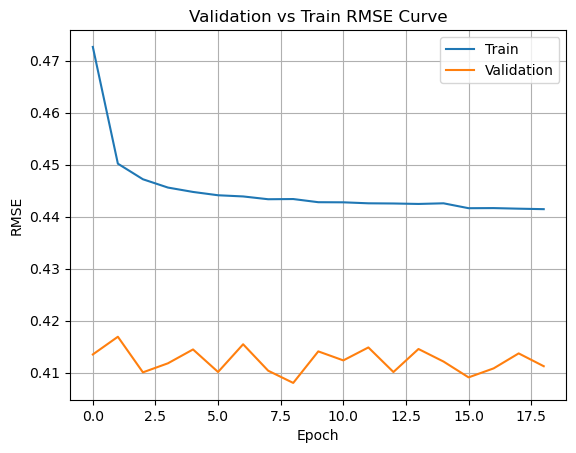

/Users/yeganehkhabbazian/miniconda3/envs/weather/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.



📊 Validation Set Performance (Real Units):
✅ RMSE: 3.2521
✅ MAE : 2.5155
Testing DataLoader 0: 100%|██████████| 2633/2633 [00:12<00:00, 219.31it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss           0.1986161470413208
        test_mae            0.34247615933418274
        test_rmse           0.42487847805023193
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

📊 Test Set Performance by Lead Day (Real Units):
                 N       MAE      RMSE
lead_time                             
1.0        84238.0  2.254044  2.944437
3.0        84238.0  2.635620  3.429990
5.0        84238.0  2.769520  3.573092
7.0        84238.0  2.795948  3.615846

📊 Test Set Perfo

In [7]:
loss_callback = rmse_callback  # ✅ This is the actual callback from trainer


# -----------------------------
# Plot RMSE curve
# -----------------------------
plt.plot(loss_callback.train_losses, label="Train")
plt.plot(loss_callback.val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Validation vs Train RMSE Curve")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Validation evaluation
# -----------------------------
X_val_tensor = torch.from_numpy(datamodule.val_data).float()
y_val_tensor = torch.from_numpy(datamodule.val_label).float()

best_model = FullyConnectedFunctional.load_from_checkpoint(checkpoint_cb.best_model_path)
best_model.eval()

with torch.no_grad():
    y_pred_val = best_model(X_val_tensor.to(best_model.device))

y_pred_val_real = scaler_y.inverse_transform(y_pred_val.cpu().numpy().reshape(-1, 1)).flatten()
y_true_val_real = scaler_y.inverse_transform(y_val_tensor.cpu().numpy().reshape(-1, 1)).flatten()

val_rmse = np.sqrt(mean_squared_error(y_true_val_real, y_pred_val_real))
val_mae = mean_absolute_error(y_true_val_real, y_pred_val_real)

print("\n📊 Validation Set Performance (Real Units):")
print(f"✅ RMSE: {val_rmse:.4f}")
print(f"✅ MAE : {val_mae:.4f}")

# -----------------------------
# Test Set Evaluation
# -----------------------------
trainer.test(best_model, dataloaders=datamodule.test_dataloader())

X_test_tensor = torch.from_numpy(datamodule.test_data).float().to(best_model.device)
y_test_tensor = torch.from_numpy(datamodule.test_label).float()
lead_time_test_tensor = torch.from_numpy(datamodule.test_lead_time).float()
lead_time_test = lead_time_test_tensor.numpy()

with torch.no_grad():
    y_pred = best_model(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()

# Scaled metrics
rmse_scaled = np.sqrt(mean_squared_error(y_true, y_pred))
mae_scaled = mean_absolute_error(y_true, y_pred)

# Convert to Kelvin
y_pred_real = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).flatten()
y_true_real = scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()

rmse_kelvin = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
mae_kelvin = mean_absolute_error(y_true_real, y_pred_real)

# Per-lead-day RMSE
df = pd.DataFrame({
    "lead_time": lead_time_test,
    "y_true": y_true_real,
    "y_pred": y_pred_real
})

grouped = df.groupby("lead_time").apply(
    lambda g: pd.Series({
        "N": len(g),
        "MAE": np.mean(np.abs(g.y_pred - g.y_true)),
        "RMSE": np.sqrt(np.mean((g.y_pred - g.y_true)**2))
    }),
    include_groups=False
)

print("\n📊 Test Set Performance by Lead Day (Real Units):")
print(grouped)

print("\n📊 Test Set Performance:")
print(f"📉 Scaled RMSE : {rmse_scaled:.4f}")
print(f"📉 Scaled MAE  : {mae_scaled:.4f}")
print(f"🌡️ Real RMSE   : {rmse_kelvin:.4f} K")
print(f"🌡️ Real MAE    : {mae_kelvin:.4f} K")


🔍 Learning rate in best model checkpoint: 0.0001


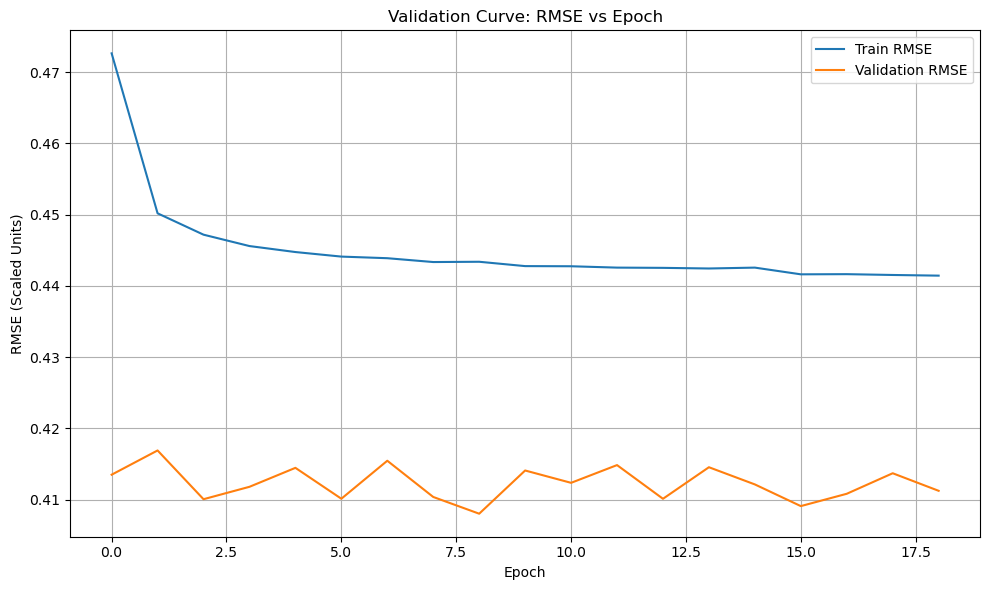

In [8]:
# Load the best checkpointed model
best_model = FullyConnectedFunctional.load_from_checkpoint(checkpoint_cb.best_model_path)

# Print the learning rate from the checkpoint
print("🔍 Learning rate in best model checkpoint:", best_model.hparams.learning_rate)

# Plot RMSE curve
import matplotlib.pyplot as plt

epochs = list(range(len(loss_callback.train_losses)))

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_callback.train_losses, label="Train RMSE")
plt.plot(epochs, loss_callback.val_losses, label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE (Scaled Units)")
plt.title("Validation Curve: RMSE vs Epoch")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🎯 Mean Bias Error (MBE): -0.4476 K


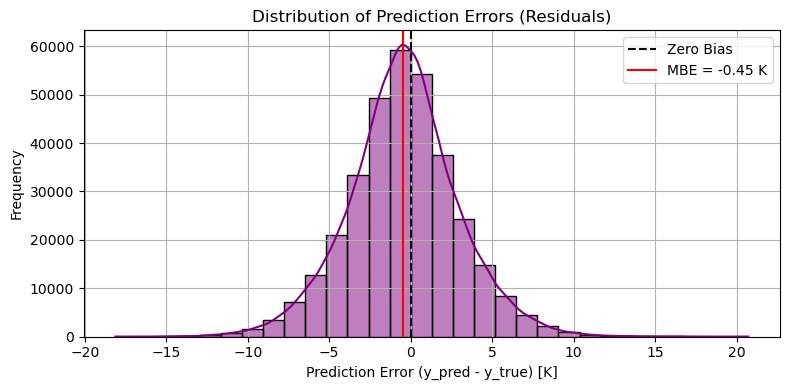

In [9]:
# -----------------------------
# Mean Bias Error (MBE)
# -----------------------------
mbe_kelvin = np.mean(y_pred_real - y_true_real)

print(f"🎯 Mean Bias Error (MBE): {mbe_kelvin:.4f} K")

# -----------------------------
# Residual Analysis Plot
# -----------------------------
import seaborn as sns

residuals = y_pred_real - y_true_real

plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--', label='Zero Bias')
plt.axvline(mbe_kelvin, color='red', linestyle='-', label=f'MBE = {mbe_kelvin:.2f} K')
plt.xlabel("Prediction Error (y_pred - y_true) [K]")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors (Residuals)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


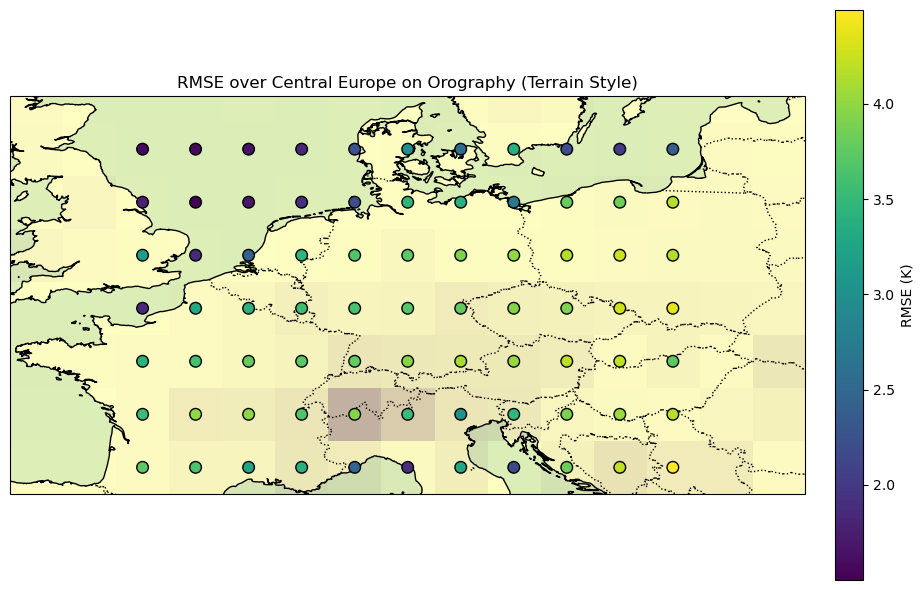

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
num_locations = len(latlon_grid)
latitudes_all = np.array([lat for lat, lon in latlon_grid])
longitudes_all = np.array([lon for lat, lon in latlon_grid])


# Step 1: Reshape (assumes 2D: locations × time)
y_true_2d = y_true_real.reshape(num_locations, -1)
y_pred_2d = y_pred_real.reshape(num_locations, -1)

# Step 2: Compute RMSE per grid point
rmse_per_point = np.sqrt(np.mean((y_pred_2d - y_true_2d) ** 2, axis=1))

# Step 3: Make sure you have lat/lon arrays
# For example: (these should match the order of predictions)
# all_lats = [50.0, 52.0, 54.0, ...]
# all_lons = [10.0, 12.0, 14.0, ...]

# Step 4: Plot


# Step 1: Convert geopotential to meters
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 1. Convert orography to meters
z_height = z_data / 9.80665

# 2. Prepare lat/lon arrays (1 per grid point)
latitudes_all = np.array([lat for lat, lon in latlon_grid])
longitudes_all = np.array([lon for lat, lon in latlon_grid])

# 3. Plot
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-5, 25, 43, 58], crs=ccrs.PlateCarree())

# 4. Add base map features
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="white")  # let terrain colormap show through
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.coastlines()

# 5. Plot orography as colored background
z_height.plot.imshow(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='terrain',     # terrain-style colormap (green-brown-gray)
    alpha=0.6,
    add_colorbar=False,
    zorder=0
)

# 6. Plot RMSE dots on top
sc = ax.scatter(
    longitudes_all, latitudes_all,
    c=rmse_per_point,
    cmap='viridis',
    s=70,
    edgecolor='k',
    zorder=3
)

# 7. Colorbar for RMSE
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.03)
cbar.set_label("RMSE (K)")

# 8. Title and layout
plt.title("RMSE over Central Europe on Orography (Terrain Style)")
plt.tight_layout()
plt.show()



🗻 Z range for plot: -9.4 to 2149.4 m


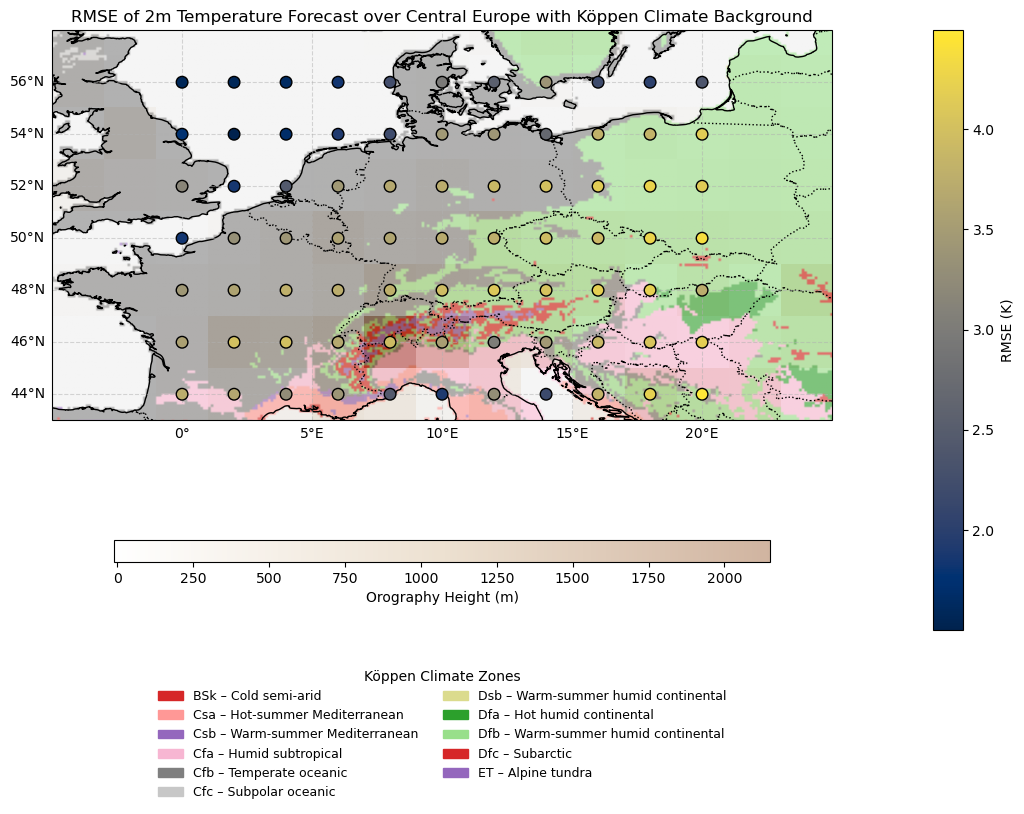

In [64]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np
import rasterio
from sklearn.metrics import mean_squared_error
from matplotlib.colors import LinearSegmentedColormap

white_to_darkbrown = LinearSegmentedColormap.from_list(
    "white_darkbrown", ["#ffffff", "#d2b48c", "saddlebrown"]  # white → tan → dark brown
)

# --- Compute RMSE per location ---
y_pred_2d = y_pred_real.reshape(len(latlon_grid), -1)
y_true_2d = y_true_real.reshape(len(latlon_grid), -1)
rmse_per_point = np.sqrt(np.mean((y_pred_2d - y_true_2d) ** 2, axis=1))

# --- Prepare lat/lon arrays ---
latitudes_all = np.array([lat for lat, lon in latlon_grid])
longitudes_all = np.array([lon for lat, lon in latlon_grid])

# --- Load Köppen raster ---
src_koppen = rasterio.open("/Users/yeganehkhabbazian/Downloads/koppen_geiger_0p1.tif")
koppen_data = src_koppen.read(1)
transform = src_koppen.transform

# --- Define full names for known Köppen classes ---
koppen_lookup_full = {
    "Cfb": "Temperate Oceanic",
    "Dfb": "Cold Continental",
    "Dfc": "Cold Subarctic",
    "ET":  "Alpine Tundra",
    "Cfa": "Humid Subtropical",
    "Unknown": "Unknown"
}

# --- Assign random distinct colors (tab20) ---
color_map = plt.cm.tab20.colors
koppen_color_map = {code: color_map[i % 20] for i, code in enumerate(koppen_code_to_abbrev.keys())}

# --- Prepare RGBA image from raster ---
colored_koppen = np.zeros((*koppen_data.shape, 4))
present_codes = np.unique(koppen_data)
present_codes = [c for c in present_codes if c in koppen_code_to_abbrev]
for code in present_codes:
    color = koppen_color_map.get(code, "#f0f0f0")
    rgba = plt.matplotlib.colors.to_rgba(color)
    colored_koppen[koppen_data == code] = rgba

# Set unknown areas to light gray
colored_koppen[(koppen_data < 1) | (koppen_data > 30)] = plt.matplotlib.colors.to_rgba("#f0f0f0")


# --- Get extent of raster ---
left, bottom = transform * (0, koppen_data.shape[0])
right, top = transform * (koppen_data.shape[1], 0)
extent = [left, right, bottom, top]
# --- Load and convert orography z ---
z_height = z_data / 9.80665  # convert to meters

# --- Crop to map extent
lat_min, lat_max = 43, 58
lon_min, lon_max = -5, 25
z_crop = z_height.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
min_z = float(z_crop.min())
max_z = float(z_crop.max())
print(f"🗻 Z range for plot: {min_z:.1f} to {max_z:.1f} m")

# --- Plot ---
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-5, 25, 43, 58], crs=ccrs.PlateCarree())

# --- Background Köppen shading ---
ax.imshow(colored_koppen, origin='upper', extent=extent, transform=ccrs.PlateCarree(), zorder=0)
im = z_height.plot.imshow(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=white_to_darkbrown,
    alpha=0.4,
    zorder=1,
    vmin=min_z,
    vmax=max_z,
    add_colorbar=False
)

# --- Borders and coastlines ---
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# --- Gridlines with lat/lon labels ---
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# --- RMSE scatter plot with red for high values ---
sc = ax.scatter(
    longitudes_all, latitudes_all,
    c=rmse_per_point,
    cmap='cividis',  # 👈 more clear and intuitive
    s=70,
    edgecolor='k',
    zorder=3
)


# --- Colorbar for RMSE ---
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("RMSE (K)")

# --- Legend for Köppen classes (only those present) ---
# --- Full Köppen code → abbreviation ---
koppen_code_to_abbrev = {
    1: "Af", 2: "Am", 3: "Aw", 4: "BWh", 5: "BWk", 6: "BSh", 7: "BSk",
    8: "Csa", 9: "Csb", 10: "Csc", 11: "Cwa", 12: "Cwb", 13: "Cwc",
    14: "Cfa", 15: "Cfb", 16: "Cfc", 17: "Dsa", 18: "Dsb", 19: "Dsc", 20: "Dsd",
    21: "Dwa", 22: "Dwb", 23: "Dwc", 24: "Dwd", 25: "Dfa", 26: "Dfb",
    27: "Dfc", 28: "Dfd", 29: "ET", 30: "EF"
}

# --- Abbreviation → full descriptive name ---
koppen_abbrev_to_full = {
    "Af": "Tropical rainforest",      "Am": "Tropical monsoon",
    "Aw": "Tropical savanna",         "BWh": "Hot desert",
    "BWk": "Cold desert",             "BSh": "Hot semi-arid",
    "BSk": "Cold semi-arid",          "Csa": "Hot-summer Mediterranean",
    "Csb": "Warm-summer Mediterranean", "Csc": "Cold-summer Mediterranean",
    "Cwa": "Subtropical monsoon",     "Cwb": "Subtropical highland",
    "Cwc": "Cold subtropical highland","Cfa": "Humid subtropical",
    "Cfb": "Temperate oceanic",       "Cfc": "Subpolar oceanic",
    "Dsa": "Hot-summer humid continental", "Dsb": "Warm-summer humid continental",
    "Dsc": "Cold-summer humid continental", "Dsd": "Extremely cold-summer continental",
    "Dwa": "Monsoon-influenced humid continental", "Dwb": "Dry-winter warm-summer continental",
    "Dwc": "Dry-winter cold-summer continental", "Dwd": "Dry-winter extremely cold-summer continental",
    "Dfa": "Hot humid continental",   "Dfb": "Warm-summer humid continental",
    "Dfc": "Subarctic",               "Dfd": "Extremely cold subarctic",
    "ET": "Alpine tundra",            "EF": "Polar ice cap"
}

# --- Assign random distinct colors (tab20) ---
color_map = plt.cm.tab20.colors
koppen_color_map = {code: color_map[i % 20] for i, code in enumerate(koppen_code_to_abbrev.keys())}

# --- Extract only classes present in your map ---
present_codes = np.unique(koppen_data)
present_codes = [c for c in present_codes if c in koppen_code_to_abbrev]

# --- Generate legend handles ---
# --- Get raster window matching your map extent ---
row_start, col_start = src_koppen.index(lon_min, lat_max)
row_stop, col_stop = src_koppen.index(lon_max, lat_min)
koppen_crop = koppen_data[min(row_start, row_stop):max(row_start, row_stop),
                          min(col_start, col_stop):max(col_start, col_stop)]

# --- Detect only present Köppen classes in the plotted area ---
present_codes = np.unique(koppen_crop)
present_codes = [c for c in present_codes if c in koppen_code_to_abbrev]

# --- Generate legend handles for present classes only ---
legend_patches = []
for c in present_codes:
    abbrev = koppen_code_to_abbrev[c]
    full_name = koppen_abbrev_to_full.get(abbrev, "Unknown")
    color = koppen_color_map[c]
    label = f"{abbrev} – {full_name}"
    patch = mpatches.Patch(color=color, label=label)
    legend_patches.append(patch)

# --- Place legend ---
plt.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -1),
           ncol=2, fontsize=9, title="Köppen Climate Zones", frameon=False)

cbar_z = plt.colorbar(
    im,
    ax=ax,
    orientation='horizontal',
    pad=0.2,
    shrink=0.7,
    aspect=30
)
cbar_z.set_label("Orography Height (m)")

# --- Final touches ---
plt.title("RMSE of 2m Temperature Forecast over Central Europe with Köppen Climate Background")
plt.tight_layout()
plt.show()


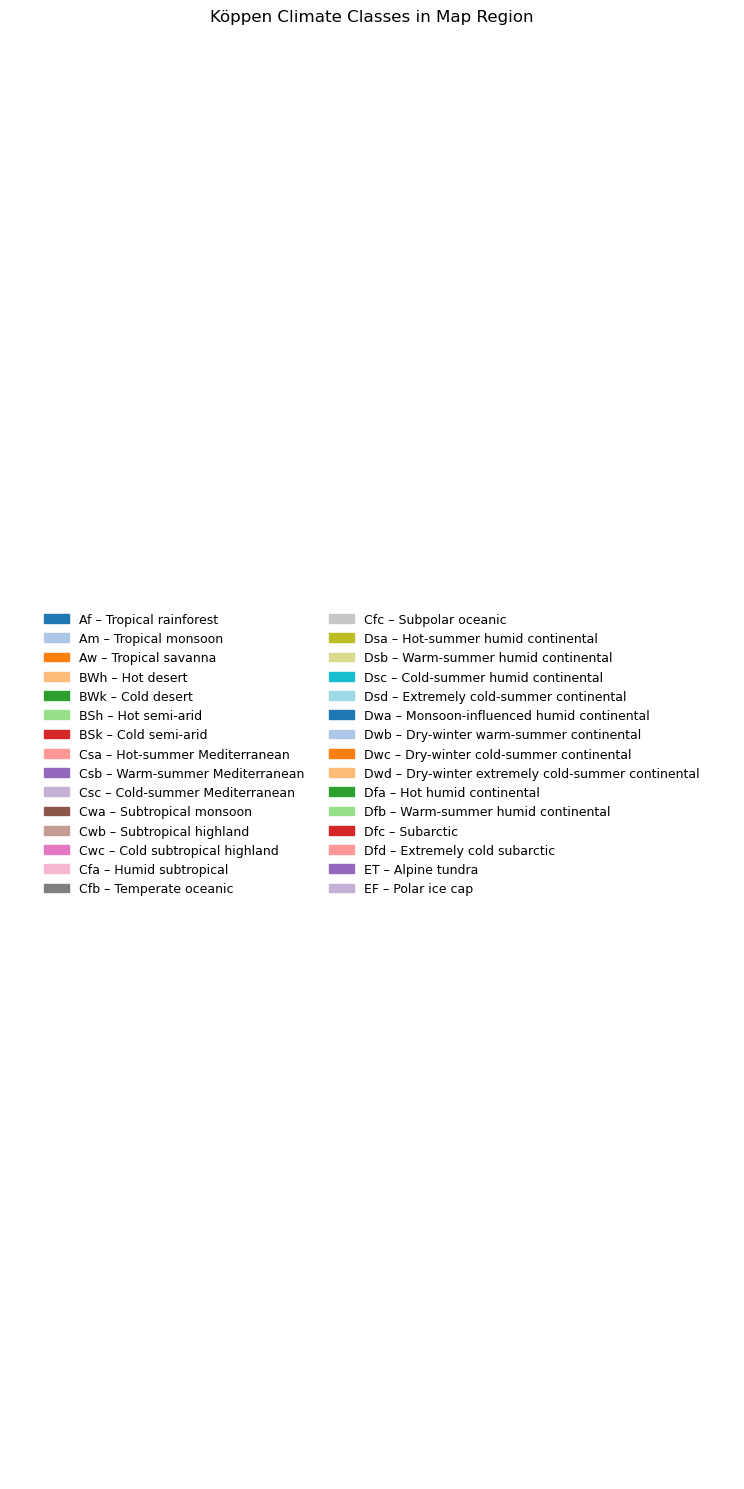

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import rasterio
from matplotlib.colors import to_rgba

# --- Step 1: Load raster ---
src_koppen = rasterio.open("/Users/yeganehkhabbazian/Downloads/koppen_geiger_0p1.tif")
koppen_data = src_koppen.read(1)

# --- Step 2: Lookup dictionaries ---

koppen_code_to_class = {
    1: "Af", 2: "Am", 3: "Aw", 4: "BWh", 5: "BWk", 6: "BSh", 7: "BSk",
    8: "Csa", 9: "Csb", 10: "Csc", 11: "Cwa", 12: "Cwb", 13: "Cwc",
    14: "Cfa", 15: "Cfb", 16: "Cfc", 17: "Dsa", 18: "Dsb", 19: "Dsc", 20: "Dsd",
    21: "Dwa", 22: "Dwb", 23: "Dwc", 24: "Dwd", 25: "Dfa", 26: "Dfb",
    27: "Dfc", 28: "Dfd", 29: "ET", 30: "EF"
}

koppen_code_to_full_name = {
    "Af": "Tropical rainforest",
    "Am": "Tropical monsoon",
    "Aw": "Tropical savanna",
    "BWh": "Hot desert",
    "BWk": "Cold desert",
    "BSh": "Hot semi-arid",
    "BSk": "Cold semi-arid",
    "Csa": "Hot-summer Mediterranean",
    "Csb": "Warm-summer Mediterranean",
    "Csc": "Cold-summer Mediterranean",
    "Cwa": "Subtropical monsoon",
    "Cwb": "Subtropical highland",
    "Cwc": "Cold subtropical highland",
    "Cfa": "Humid subtropical",
    "Cfb": "Temperate oceanic",
    "Cfc": "Subpolar oceanic",
    "Dsa": "Hot-summer humid continental",
    "Dsb": "Warm-summer humid continental",
    "Dsc": "Cold-summer humid continental",
    "Dsd": "Extremely cold-summer continental",
    "Dwa": "Monsoon-influenced humid continental",
    "Dwb": "Dry-winter warm-summer continental",
    "Dwc": "Dry-winter cold-summer continental",
    "Dwd": "Dry-winter extremely cold-summer continental",
    "Dfa": "Hot humid continental",
    "Dfb": "Warm-summer humid continental",
    "Dfc": "Subarctic",
    "Dfd": "Extremely cold subarctic",
    "ET": "Alpine tundra",
    "EF": "Polar ice cap"
}

# Choose colors for all 30 classes (or only your subset later)
# Example only — customize later
koppen_color_map = {
    code: plt.cm.tab20(i % 20) for i, code in enumerate(koppen_code_to_class.keys())
}

# --- Step 3: Get only codes present in your data ---
present_codes = np.unique(koppen_data)
present_codes = [code for code in present_codes if code in koppen_code_to_class]

# --- Step 4: Prepare legend handles (color, label) ---
legend_handles = []
for code in present_codes:
    abbrev = koppen_code_to_class[code]
    full_name = koppen_code_to_full_name.get(abbrev, "Unknown")
    color = koppen_color_map[code]
    label = f"{abbrev} – {full_name}"
    patch = mpatches.Patch(color=color, label=label)
    legend_handles.append(patch)

# --- OPTIONAL: Show legend only ---
fig, ax = plt.subplots(figsize=(8, len(legend_handles) // 2))
ax.axis("off")
plt.legend(handles=legend_handles, loc="center", frameon=False, ncol=2, fontsize=9)
plt.title("Köppen Climate Classes in Map Region")
plt.tight_layout()
plt.show()


🗻 Local orography range: -9.4 m to 2149.4 m


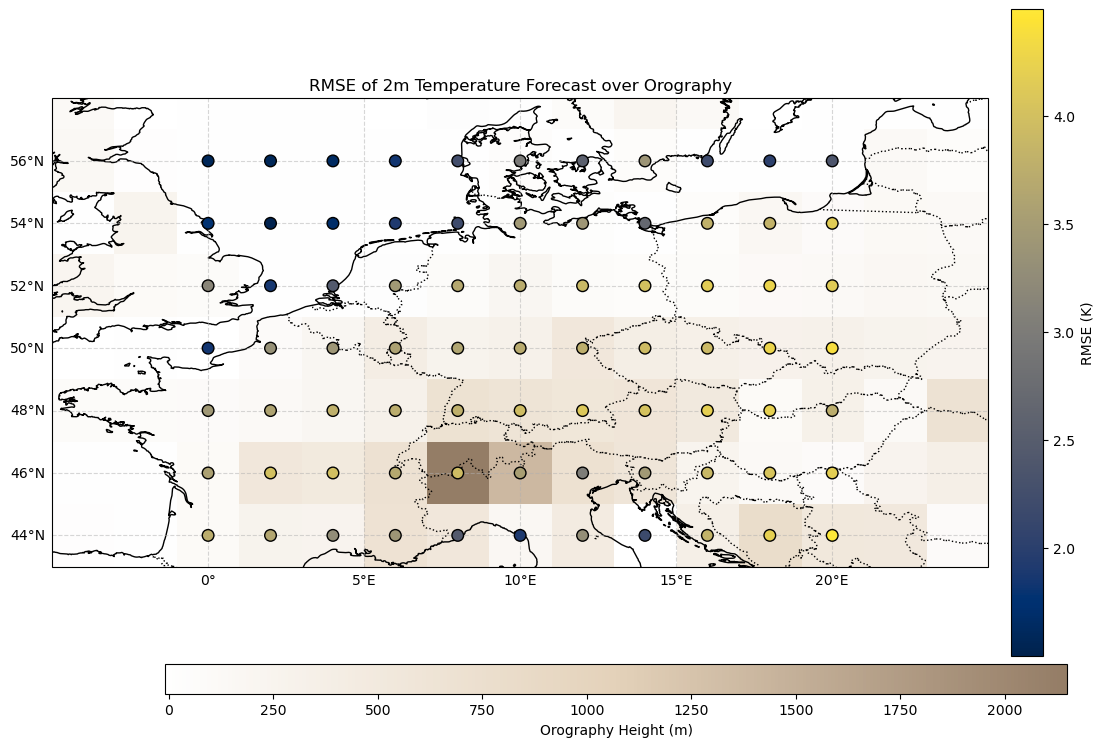

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import mean_squared_error

# --- Step 1: Compute RMSE per location ---
y_pred_2d = y_pred_real.reshape(len(latlon_grid), -1)
y_true_2d = y_true_real.reshape(len(latlon_grid), -1)
rmse_per_point = np.sqrt(np.mean((y_pred_2d - y_true_2d) ** 2, axis=1))

# --- Step 2: Prepare lat/lon arrays ---
latitudes_all = np.array([lat for lat, lon in latlon_grid])
longitudes_all = np.array([lon for lat, lon in latlon_grid])

# --- Step 3: Convert geopotential to height in meters ---
z_height = z_data / 9.80665  # [m²/s²] → [m]

# --- Step 4: Define custom white→brown colormap ---
white_to_brown = LinearSegmentedColormap.from_list(
    "white_brown", ["#ffffff", "#d2b48c", "#4d2600"]  # white → tan → brown
)

# --- Step 5: Plot ---
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-5, 25, 43, 58], crs=ccrs.PlateCarree())

# --- Orography as background (white → brown)
# --- Compute min/max over the plotted extent ---
lat_min, lat_max = 43, 58
lon_min, lon_max = -5, 25

# Crop the z_height to region
# --- Compute min/max for Central Europe
lat_min, lat_max = 43, 58
lon_min, lon_max = -5, 25
z_crop = z_height.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
min_z = float(z_crop.min())
max_z = float(z_crop.max())
print(f"🗻 Local orography range: {min_z:.1f} m to {max_z:.1f} m")

# --- Plot with local vmin/vmax and dark brown
im = z_height.plot.imshow(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=white_to_brown,
    alpha=0.6,
    zorder=0,
    vmin=min_z,
    vmax=max_z,
    add_colorbar=False  # we'll add it manually
)

# --- Add orography colorbar manually
cbar_z = plt.colorbar(
    im,
    ax=ax,
    orientation='horizontal',
    pad=0.01,       # spacing from map
    shrink=0.8,     # width of colorbar relative to map
    aspect=30       # thickness
)
cbar_z.set_label("Orography Height (m)", fontsize=10)




# --- Add map features ---
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# --- RMSE dots with cividis colormap ---
sc = ax.scatter(
    longitudes_all, latitudes_all,
    c=rmse_per_point,
    cmap='cividis',
    s=70,
    edgecolor='k',
    zorder=3
)

# --- Colorbar for RMSE ---
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label("RMSE (K)")

# --- Final touches ---
plt.title("RMSE of 2m Temperature Forecast over Orography")
plt.tight_layout()
plt.show()


In [13]:
print("📐 Shape check:")

# Check how many grid points you have
print("latlon_grid:", len(latlon_grid))  # should be 66 if it's 11x6

# Check shapes of prediction and truth arrays
print("y_pred_real shape:", y_pred_real.shape)
print("y_true_real shape:", y_true_real.shape)

# Optionally check a few lat/lon values
print("Example latlon points:", latlon_grid[:5])  # first 5 grid points

# If you use reshaping, check if you used:
try:
    y_pred_2d = y_pred_real.reshape(len(latlon_grid), -1)
    y_true_2d = y_true_real.reshape(len(latlon_grid), -1)
    print("✅ y_pred_2d shape:", y_pred_2d.shape)
    print("✅ y_true_2d shape:", y_true_2d.shape)
except Exception as e:
    print("❌ Reshape error:", e)


📐 Shape check:
latlon_grid: 77
y_pred_real shape: (336952,)
y_true_real shape: (336952,)
Example latlon points: [(44.0, 0.0), (44.0, 2.0), (44.0, 4.0), (44.0, 6.0), (44.0, 8.0)]
✅ y_pred_2d shape: (77, 4376)
✅ y_true_2d shape: (77, 4376)


In [57]:
def compute_lrp_detailed_stats_and_plots(X_numpy, model, feature_names, label="Set", hist_features=None):
    """
    Compute detailed LRP statistics and plot them:
    - Adds dummy lead_time if X_numpy is missing it
    - Ensures shape matches model expectations and feature_names
    """
    import matplotlib.pyplot as plt
    from zennit.composites import EpsilonPlus
    from zennit.attribution import Gradient as Attribution
    import torch
    import numpy as np
 
    composite = EpsilonPlus()

    # 💡 Automatically fix if lead_time is missing
    expected_feature_count = len(feature_names)  # e.g., 50

    if X_numpy.shape[1] != expected_feature_count:
        raise ValueError(f"❌ Feature mismatch: got input shape {X_numpy.shape[1]}, but expected {expected_feature_count} based on feature_names.")

   

    # ✅ Input is now the correct shape
    X_tensor = torch.from_numpy(X_numpy).float()

    relevance_all = []
    for i in range(X_tensor.shape[0]):
        x_input = X_tensor[i].unsqueeze(0).clone().detach().requires_grad_(True).to("cpu")
        
        with Attribution(model=model, composite=composite) as attr:
            _, relevance = attr(x_input)
            relevance_all.append(relevance.detach().numpy().flatten())

    # 🔢 Statistics
    median = np.median(relevance_all, axis=0)
    percentile_25 = np.percentile(relevance_all, 25, axis=0)
    percentile_75 = np.percentile(relevance_all, 75, axis=0)
    abs_mean = np.mean(np.abs(relevance_all), axis=0)

    # 📊 Plotting
    x = np.arange(len(feature_names))
    width = 0.25

    plt.figure(figsize=(16,6))
    plt.bar(x - width, percentile_25, width, label='25th Percentile')
    plt.bar(x, median, width, label='Median')
    plt.bar(x + width, percentile_75, width, label='75th Percentile')
    plt.xticks(x, feature_names, rotation=45, ha='right')
    plt.ylabel('LRP Relevance')
    plt.title(f"LRP Relevance Percentiles per Feature ({label})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(16,4))
    plt.bar(x, abs_mean)
    plt.xticks(x, feature_names, rotation=45, ha='right')
    plt.ylabel('Mean Absolute LRP Relevance')
    plt.title(f"Mean Absolute LRP Relevance per Feature ({label})")
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(16,6))
    plt.bar(x, median, yerr=[median - percentile_25, percentile_75 - median], capsize=5)
    plt.xticks(x, feature_names, rotation=45, ha='right')
    plt.ylabel('LRP Relevance')
    plt.title(f"Median LRP Relevance ± IQR ({label})")
    plt.tight_layout()
    plt.show()
    import seaborn as sns
    

    # 🔁 Convert relevance array to DataFrame
    df = pd.DataFrame(relevance_all, columns=feature_names)

    # ✂️ Optionally: limit to fewer features to avoid overcrowding
    subset = [
        'T_500', 'T_700', 'z', 'lsm', 'sdor', 'hour_0', 'hour_12', 'month_sin',
        'lat', 'lon',  'K_Dfc'
    ]

  # or use hist_features to be consistent

    plt.figure(figsize=(16, 5))
    ax = sns.boxplot(data=df[subset])
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)  # ✨ Add y=0 line
    plt.xticks(rotation=45, ha='right')
    plt.title(f"LRP Relevance Distribution (Boxplot) — {label}")
    plt.tight_layout()
    plt.show()


    relevance_all = np.array(relevance_all)

    if hist_features is not None:
        bins = np.linspace(np.min(relevance_all), np.max(relevance_all), 50)
        for idx in hist_features:
            plt.figure(figsize=(6,4))
            plt.hist(relevance_all[:, idx], bins=bins, alpha=0.6)
            plt.title(f"LRP Relevance Distribution for {feature_names[idx]} ({label})")
            plt.xlabel("Relevance")
            plt.ylabel("Frequency")
            plt.tight_layout()
            plt.show()

    # 🎯 OPTIONAL: Boxplots by Lead Time (for selected features)
    selected_features = ['T_500', 'T_700', 'z', 'hour_0', 'hour_12', 'month_sin']
    lt_columns = ['LT_1', 'LT_3']  # or loop over all if space allows

    fig, axs = plt.subplots(1, len(lt_columns), figsize=(16, 5), sharey=True)

    for i, lt_col in enumerate(lt_columns):
        lt_mask = df[lt_col] > 0.5  # Binary one-hot encoding (1.0 for active lead time)
        axs[i].set_title(f"LRP Boxplot for {lt_col}")
        sns.boxplot(data=df.loc[lt_mask, selected_features], ax=axs[i])
        axs[i].tick_params(axis='x', rotation=45)

    fig.suptitle(f"LRP Relevance per Lead Time — {label}", fontsize=14)
    plt.tight_layout()
    plt.show()

    return relevance_all
print(all_classes)


['Af', 'Am', 'Aw', 'BSh', 'BSk', 'BWh', 'BWk', 'Cfa', 'Cfb', 'Cfc', 'Csa', 'Csb', 'Csc', 'Cwa', 'Cwb', 'Cwc', 'Dfa', 'Dfb', 'Dfc', 'Dfd', 'Dsa', 'Dsb', 'Dsc', 'Dsd', 'Dwa', 'Dwb', 'Dwc', 'Dwd', 'EF', 'ET', 'Unknown']


In [58]:
def clean_numpy_array(x):
    return np.array(x, dtype=np.float32, copy=True).view(np.ndarray)

In [59]:
# Model internals
model = best_model.model.cpu().eval()
feature_names = (
    [f"T_{lev}" for lev in levels] +          # pressure-level temps
    ["z", "lsm", "sdor"] +                    # static features
    ["hour_0", "hour_12"]
 +                                # time feature
    ["month_sin", "month_cos"] +              # seasonal features
    ["lat", "lon"] +                          # location coords
    [f"K_{cls}" for cls in all_classes] +    # Köppen classes including 'Unknown'
    ["LT_1", "LT_3", "LT_5", "LT_7"]         # lead times
)





print("Train data type:", type(datamodule.train_data))
print("Train data dtype:", getattr(datamodule.train_data, "dtype", "No dtype"))
print("Train data shape:", getattr(datamodule.train_data, "shape", "No shape"))
X_train_clean = clean_numpy_array(datamodule.train_data)
torch.from_numpy(X_train_clean)  # ✅ this should now succeed


X_val_clean   = clean_numpy_array(datamodule.val_data)
X_test_clean  = clean_numpy_array(datamodule.test_data)

Train data type: <class 'numpy.ndarray'>
Train data dtype: float32
Train data shape: (1622544, 47)


In [60]:
hist_features = [feature_names.index(f) for f in [
    'T_500', 'T_700', 'z', 'lsm', 'sdor', 'hour_0', 'hour_12', 'month_sin',
    'lat', 'lon', 'K_BWh', 'K_Dfc', 'K_ET', 'K_Unknown',
    'LT_1', 'LT_3', 'LT_5', 'LT_7'
]]

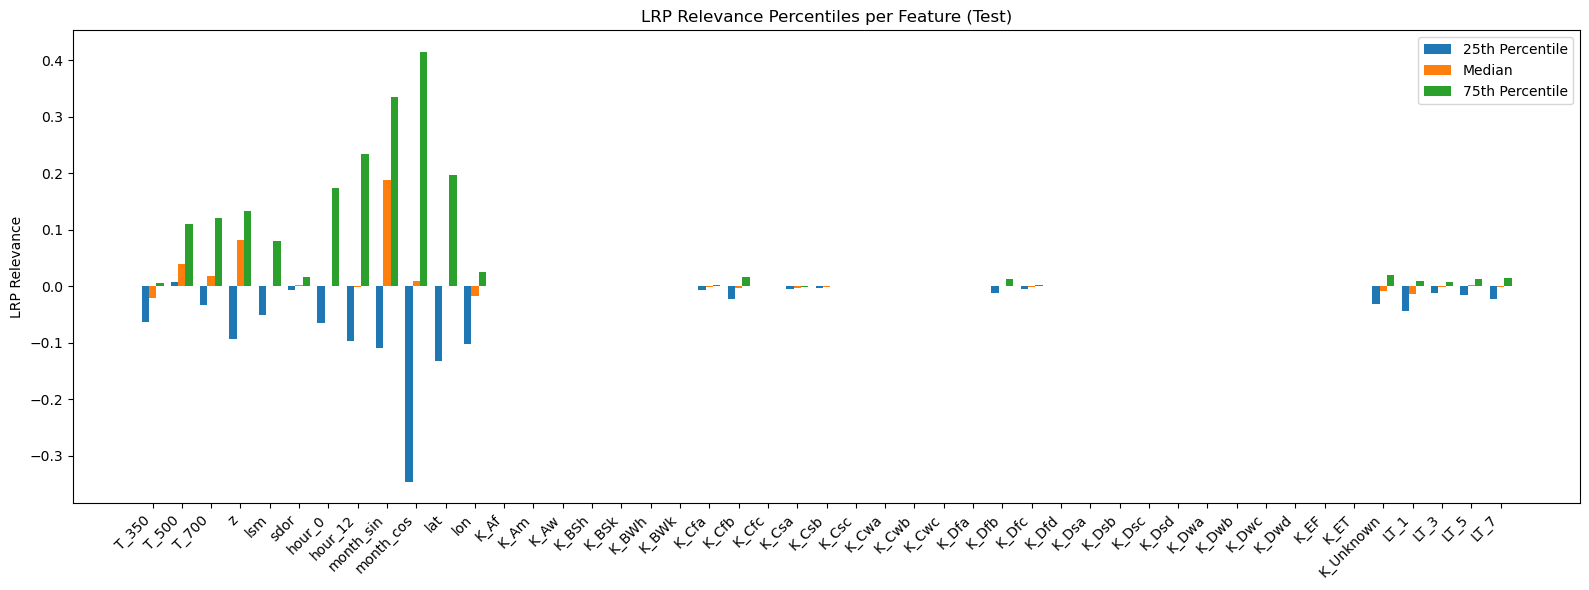

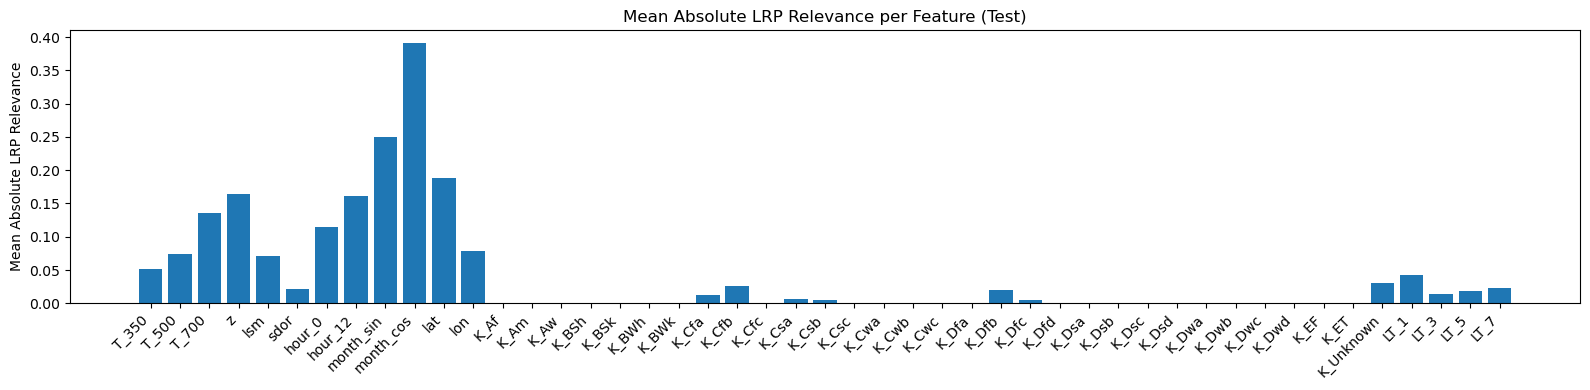

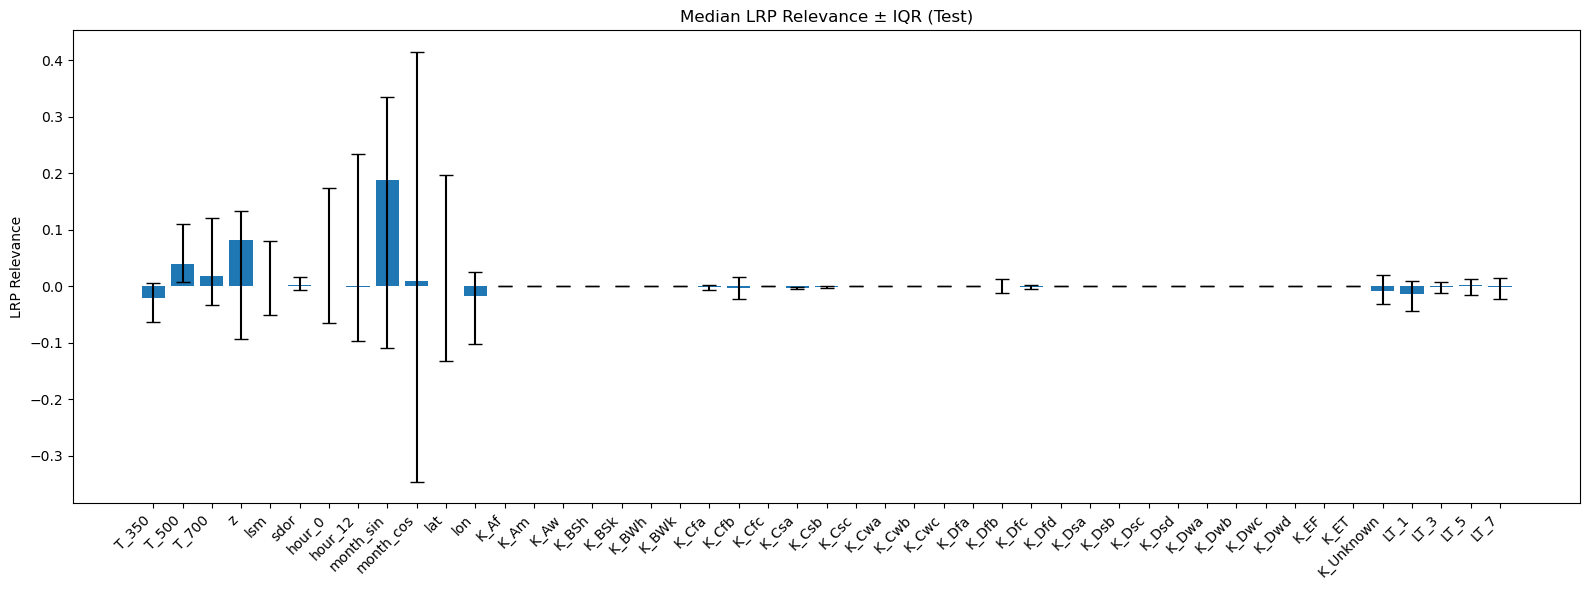

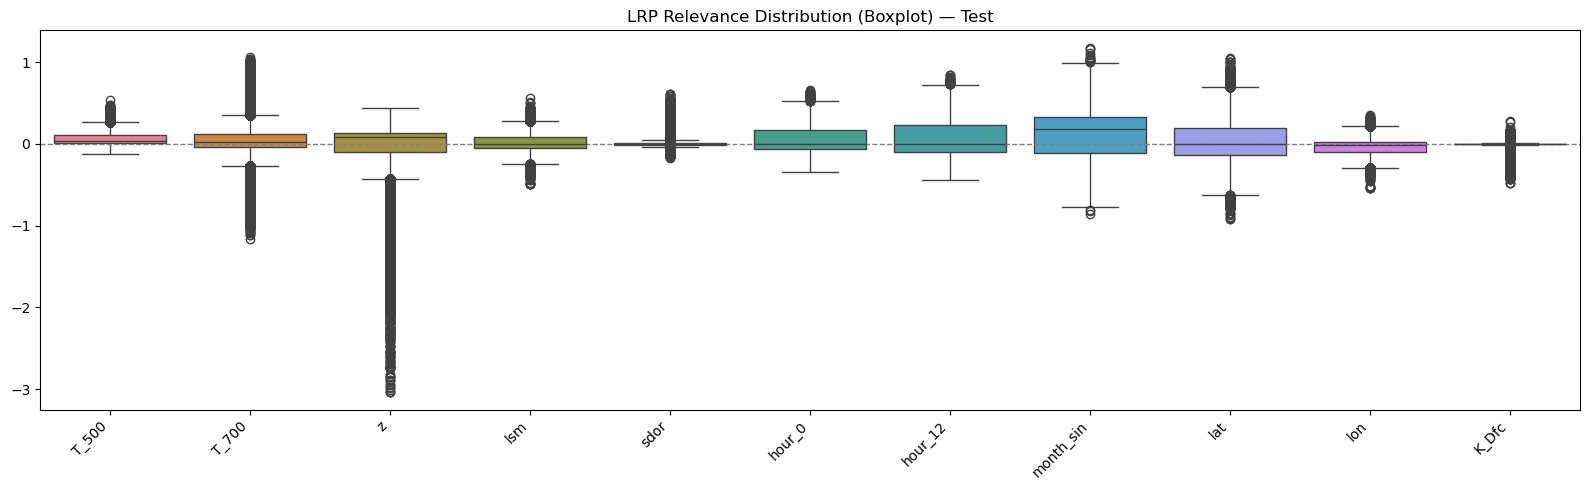

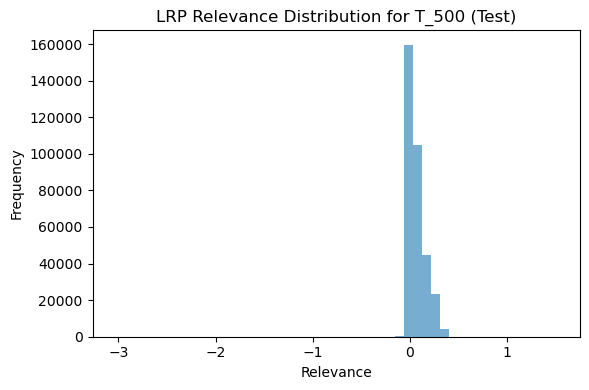

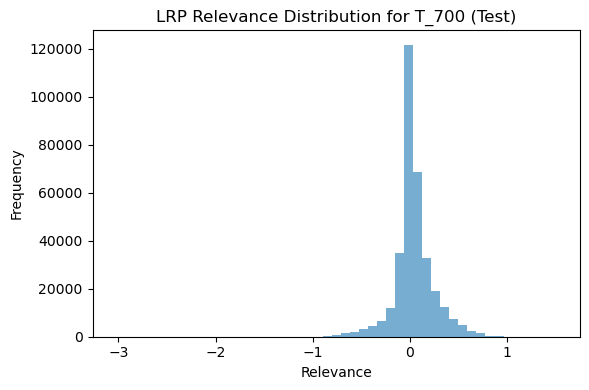

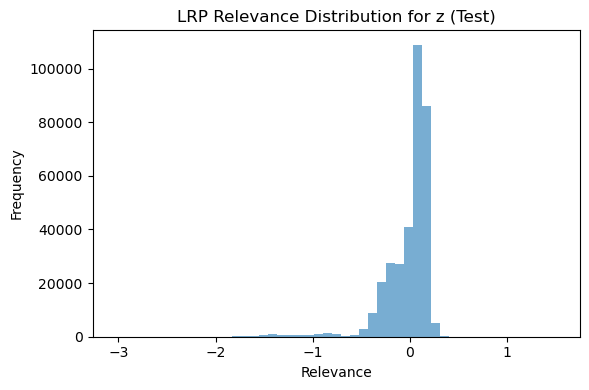

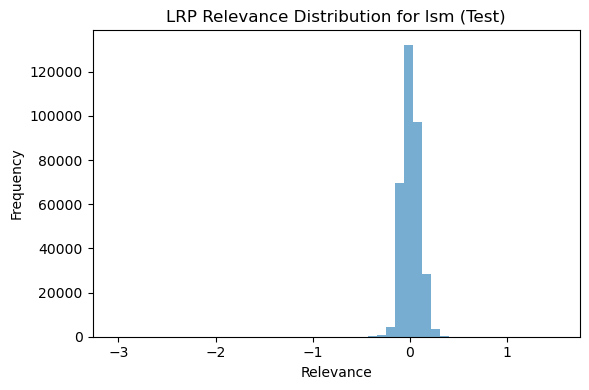

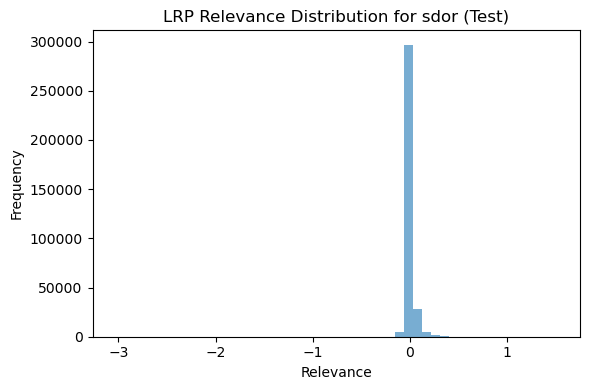

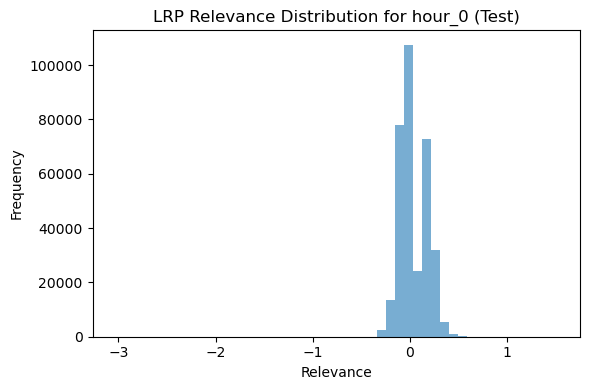

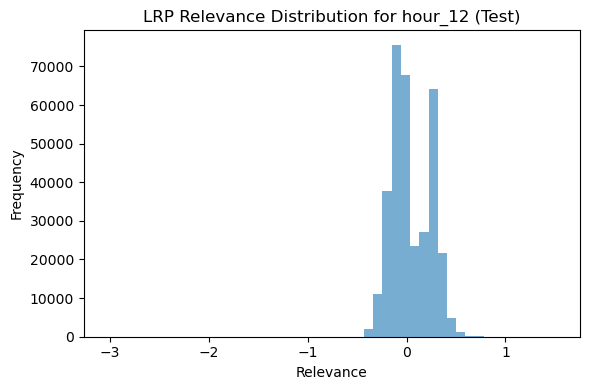

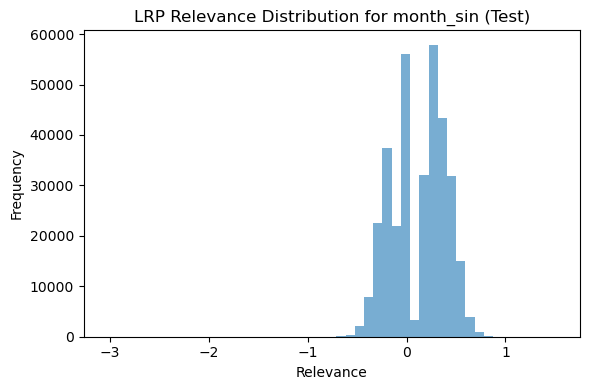

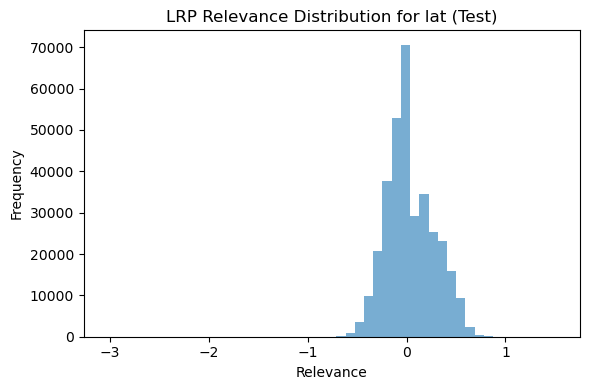

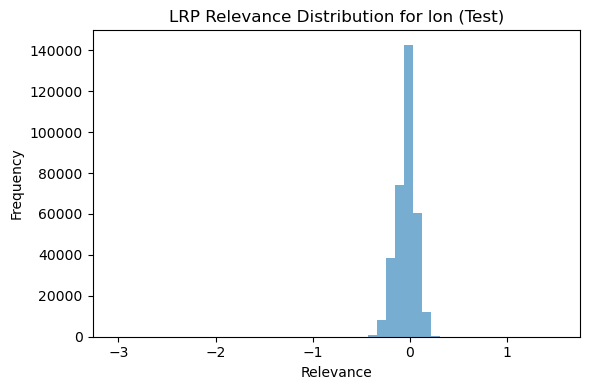

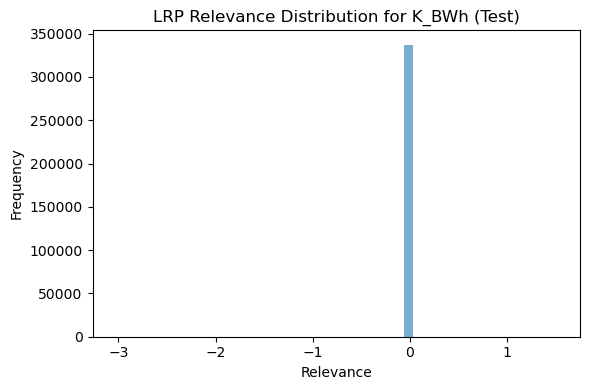

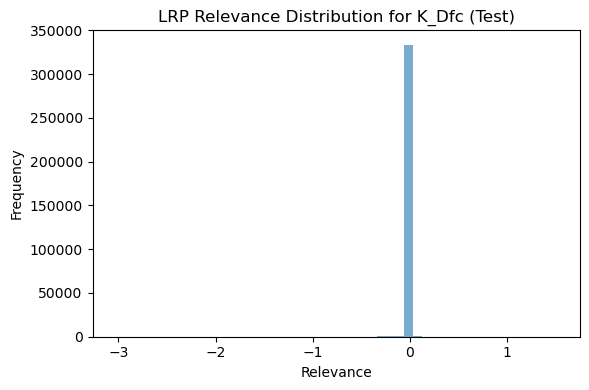

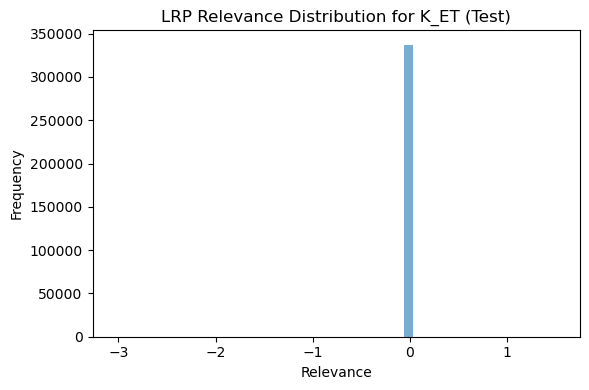

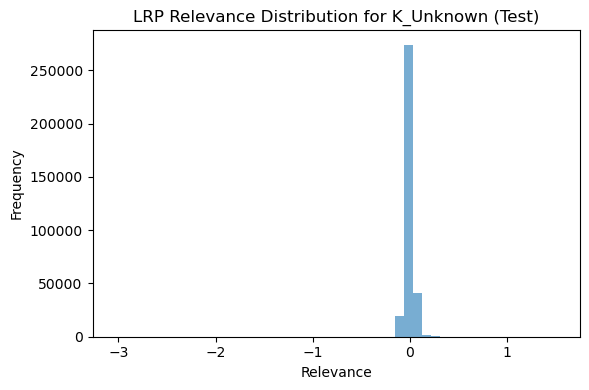

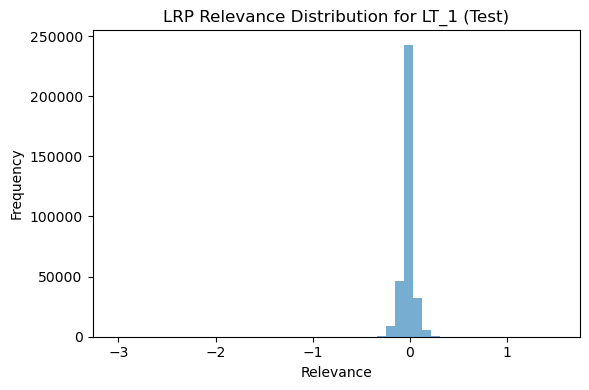

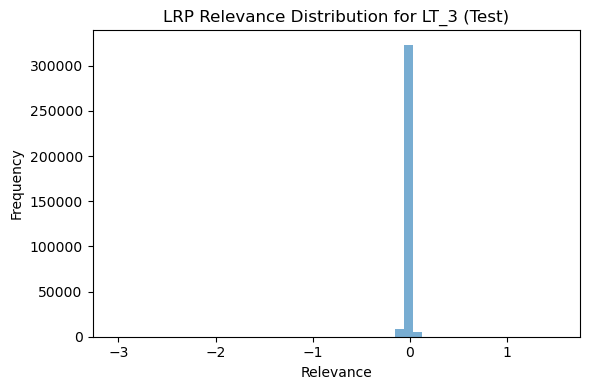

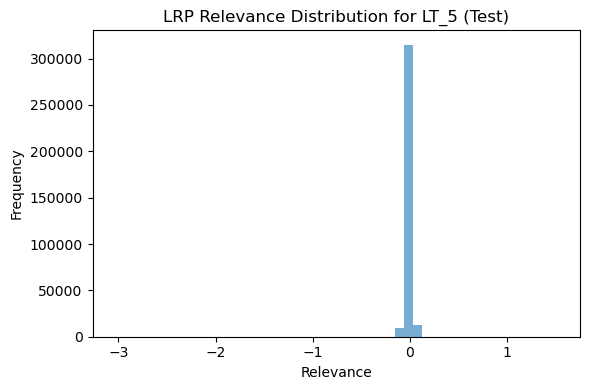

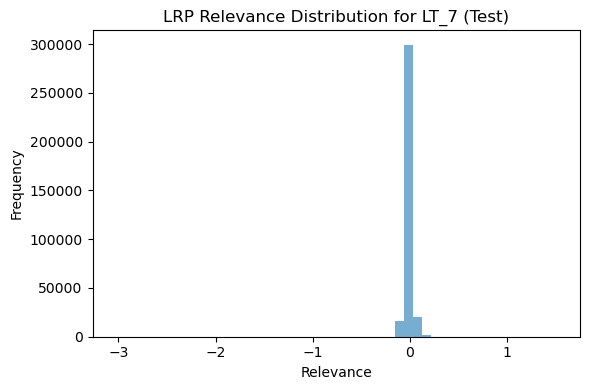

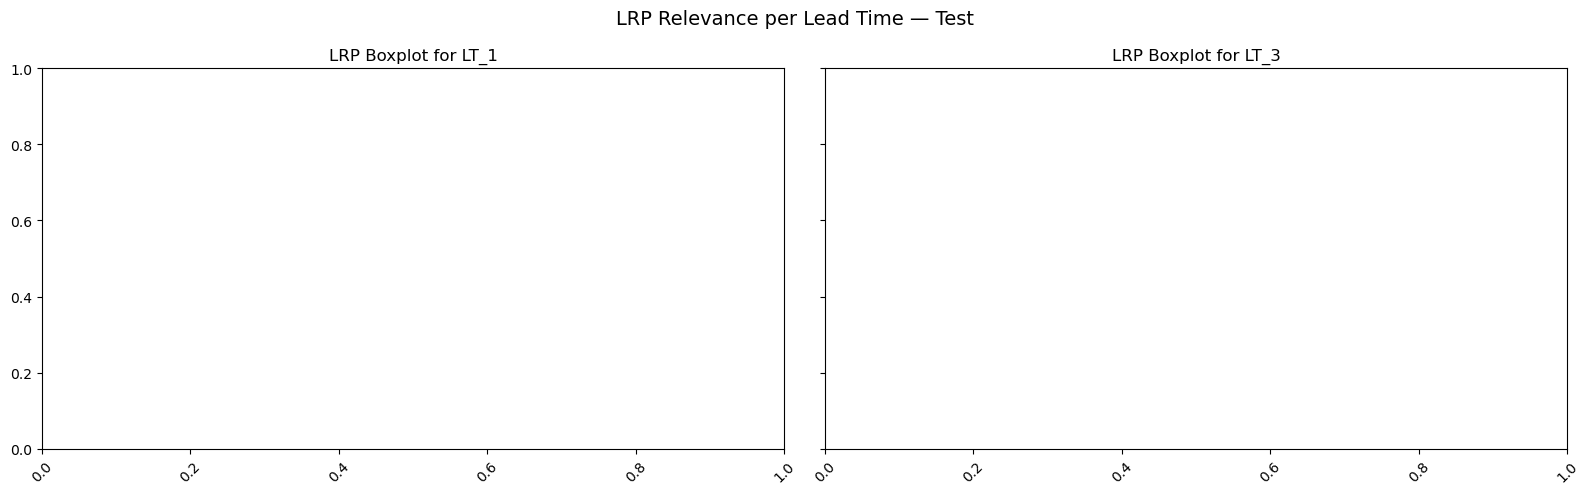

In [61]:
relevance_all = compute_lrp_detailed_stats_and_plots(
    X_test_clean, model, feature_names, label="Test", hist_features=hist_features
)


In [50]:

feature_names = (
    [f"T_{lev}" for lev in levels] +          # pressure-level temps
    ["z", "lsm", "sdor"] +                    # static features
    ["hour_0", "hour_12"]
 +                                # time feature
    ["month_sin", "month_cos"] +              # seasonal features
    ["lat", "lon"] +                          # location coords
    [f"K_{cls}" for cls in all_classes] +    # Köppen classes including 'Unknown'
    ["LT_1", "LT_3", "LT_5", "LT_7"]         # lead times
)

LRP for Lead 1: 100%|██████████| 84238/84238 [01:40<00:00, 837.99it/s]


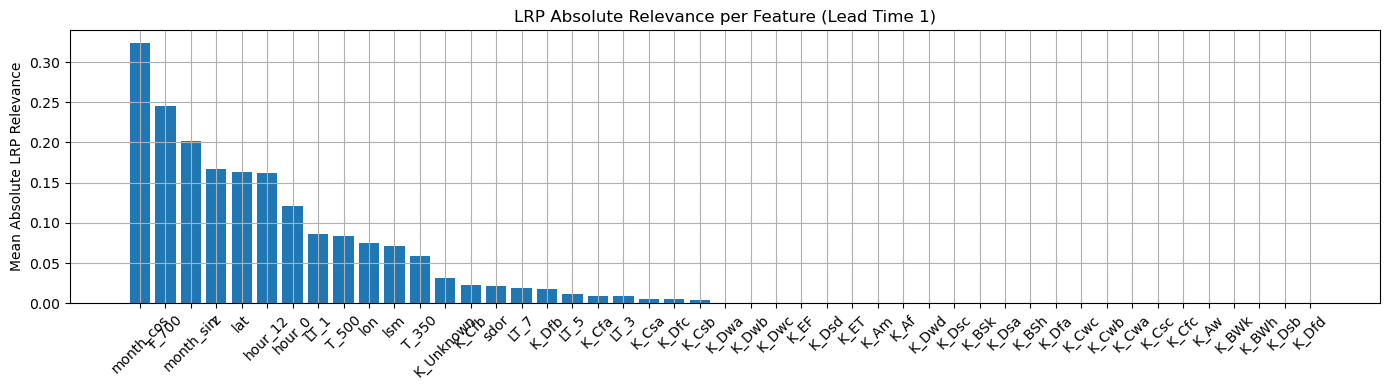

LRP for Lead 3:  34%|███▍      | 28954/84238 [00:33<01:04, 853.48it/s]


KeyboardInterrupt: 

In [51]:
from tqdm import tqdm
def compute_lrp_by_lead_time_absolute_mean(X_numpy, lead_times, model, feature_names):
    """
    For each unique lead time, compute the mean absolute LRP relevance for each feature.

    Parameters:
        X_numpy: ndarray of shape (samples, features)
        lead_times: array-like of shape (samples,) with lead times (e.g., 1, 3, 5, 7)
        model: PyTorch model (Sequential, no wrapper)
        feature_names: list of feature names

    Returns:
        dict of lead_time -> mean absolute relevance vector
    """
    X_numpy = np.array(X_numpy, dtype=np.float32)
    lead_times = np.array(lead_times)
    unique_leads = np.unique(lead_times)

    results = {}

    for lead in unique_leads:
        mask = lead_times == lead
        X_subset = X_numpy[mask]
        #print(f"🔍 Lead Time {lead}: {X_subset.shape[0]} samples")

        # Compute relevance
        composite = EpsilonPlus()
        relevance_all = []
        for i in tqdm(range(X_subset.shape[0]), desc=f"LRP for Lead {lead}"):
            x_input_arr = X_subset[i:i+1]  # Use the input directly without adding lead time again
           
            x_input = torch.tensor(x_input_arr, dtype=torch.float32, requires_grad=True)
            
            with Attribution(model=model, composite=composite) as attr:
                _, relevance = attr(x_input)
                relevance_all.append(np.abs(relevance.detach().numpy().flatten()))



        relevance_all = np.array(relevance_all)
        abs_mean = np.mean(relevance_all, axis=0)
        results[lead] = abs_mean

        # Plot
        plt.figure(figsize=(14, 4))
        sorted_idx = np.argsort(-abs_mean)  # descending
        plt.bar(np.arange(len(abs_mean)), abs_mean[sorted_idx])
        plt.xticks(np.arange(len(feature_names)), np.array(feature_names)[sorted_idx], rotation=45)

      
        plt.ylabel("Mean Absolute LRP Relevance")
        plt.title(f"LRP Absolute Relevance per Feature (Lead Time {lead})")
        plt.tight_layout()
        plt.grid(True)
        plt.show()
        
        

    return results
from zennit.composites import EpsilonPlus
from zennit.attribution import Gradient as Attribution
 
all_results = compute_lrp_by_lead_time_absolute_mean(
    X_test_clean,
    datamodule.test_lead_time,
    model,
    feature_names
)

In [ ]:
	
for lt in sorted(all_results.keys()):
    relevances = all_results[lt]
    top_idx = np.argsort(-np.abs(relevances))[:10]  # Top 5 features
    top_features = [feature_names[i] for i in top_idx]
    print(f"Lead Time {lt}: Top Features → {top_features}")

Lead Time 1: Top Features → ['month_cos', 'T_700', 'month_sin', 'z', 'lat', 'hour_12', 'hour_0', 'LT_1', 'T_500', 'lon']
Lead Time 3: Top Features → ['month_cos', 'month_sin', 'lat', 'z', 'hour_12', 'T_700', 'hour_0', 'lon', 'T_500', 'lsm']
Lead Time 5: Top Features → ['month_cos', 'month_sin', 'lat', 'z', 'hour_12', 'hour_0', 'T_700', 'lon', 'lsm', 'T_500']
Lead Time 7: Top Features → ['month_cos', 'month_sin', 'lat', 'z', 'hour_12', 'hour_0', 'lon', 'lsm', 'T_700', 'T_500']


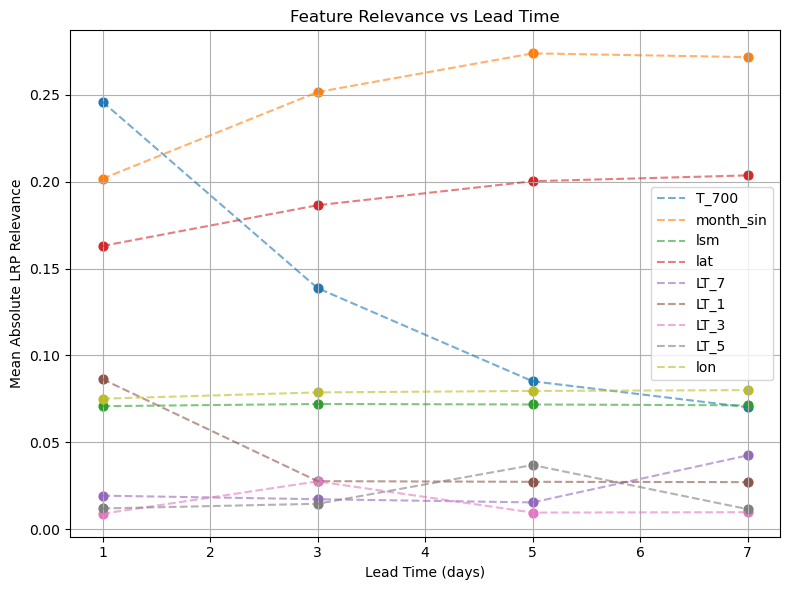

In [ ]:
import matplotlib.pyplot as plt

selected_features = ['T_700', 'month_sin', 'lsm',  'lat', 'LT_7', 'LT_1','LT_3','LT_5', 'lon']

lead_times_sorted = sorted(all_results.keys())
feature_indices = [feature_names.index(f) for f in selected_features]

# Correct Köppen slice based on actual feature names
koppen_features = [f"K_{cls}" for cls in all_classes]  # Make sure all_classes matches your data
k_start = feature_names.index(koppen_features[0])    # e.g. 'K_Af'
k_end   = feature_names.index(koppen_features[-1]) + 1  # e.g. 'K_Unknown' +1 for inclusive slice

k_sum_values = [np.sum(all_results[lt][k_start:k_end]) for lt in lead_times_sorted]

k_nonzero_mean = []
for lt in lead_times_sorted:
    k_vals = all_results[lt][k_start:k_end]
    nonzero_k = k_vals[k_vals > 1e-6]
    k_nonzero_mean.append(np.mean(nonzero_k) if len(nonzero_k) > 0 else 0)

plt.figure(figsize=(8, 6))

# Plot selected features
for idx, fname in zip(feature_indices, selected_features):
    values = [all_results[lt][idx] for lt in lead_times_sorted]
    plt.plot(lead_times_sorted, values, label=fname, linestyle='--', alpha=0.6)
    plt.scatter(lead_times_sorted, values, s=40)

# Plot Köppen sum or mean
#plt.plot(lead_times_sorted, k_nonzero_mean, label='Mean of Nonzero K_*', color='blue', linestyle='-', linewidth=2)
#plt.scatter(lead_times_sorted, k_nonzero_mean, color='blue', s=40)

plt.xlabel("Lead Time (days)")
plt.ylabel("Mean Absolute LRP Relevance")
plt.title("Feature Relevance vs Lead Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

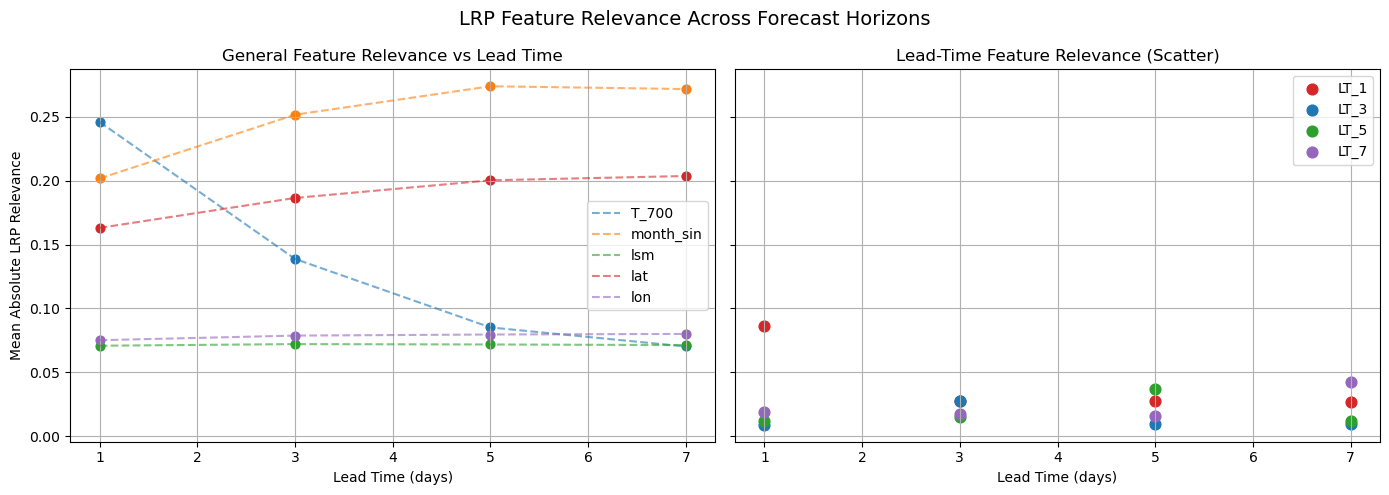

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Feature selections ---
general_features = ['T_700', 'month_sin', 'lsm', 'lat', 'lon']
lt_features = ['LT_1', 'LT_3', 'LT_5', 'LT_7']

lead_times_sorted = sorted(all_results.keys())
general_indices = [feature_names.index(f) for f in general_features]
lt_indices = [feature_names.index(f) for f in lt_features]

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 📉 Left subplot: General features
for idx in general_indices:
    values = [all_results[lt][idx] for lt in lead_times_sorted]
    axs[0].plot(lead_times_sorted, values, label=feature_names[idx], linestyle='--', alpha=0.6)
    axs[0].scatter(lead_times_sorted, values, s=40)

axs[0].set_title("General Feature Relevance vs Lead Time")
axs[0].set_xlabel("Lead Time (days)")
axs[0].set_ylabel("Mean Absolute LRP Relevance")
axs[0].legend()
axs[0].grid(True)

# 📊 Right subplot: Scatter only for lead time features
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:purple']
for idx, color in zip(lt_indices, colors):
    lt_name = feature_names[idx]
    values = [all_results[lt][idx] for lt in lead_times_sorted]
    axs[1].scatter(lead_times_sorted, values, label=lt_name, s=60, color=color)

axs[1].set_title("Lead-Time Feature Relevance (Scatter)")
axs[1].set_xlabel("Lead Time (days)")
axs[1].legend()
axs[1].grid(True)

plt.suptitle("LRP Feature Relevance Across Forecast Horizons", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
def compute_lrp_by_location_absolute_mean(X_set, model, feature_names, location_names):
    """
    Compute mean absolute relevance for each location.
    X_set: shape (num_locations, timesteps, num_features_without_lead_time)
    """
    from zennit.composites import EpsilonPlus
    from zennit.attribution import Gradient as Attribution
    import torch
    import numpy as np
    import matplotlib.pyplot as plt

    composite = EpsilonPlus()
    num_locations = X_set.shape[0]
    num_features = X_set.shape[2]
    expected_features = len(feature_names)

    results = {}

    for loc_idx in range(num_locations):
        X_loc = X_set[loc_idx]

        # 🔧 Add dummy lead time if missing
        if num_features == expected_features - 1:
            lead_time_dummy = np.zeros((X_loc.shape[0], 1), dtype=np.float32)
            X_loc = np.concatenate([X_loc, lead_time_dummy], axis=1)

        relevance_all = []

        for i in range(X_loc.shape[0]):
            x_input = torch.tensor(X_loc[i:i+1], dtype=torch.float32, requires_grad=True)
            with Attribution(model=model, composite=composite) as attr:
                _, relevance = attr(x_input)
                relevance_all.append(np.abs(relevance.detach().numpy().flatten()))

        relevance_all = np.array(relevance_all)
        abs_mean = np.mean(relevance_all, axis=0)
        results[location_names[loc_idx]] = abs_mean

    return results


Num samples with lead time 1 : 84238


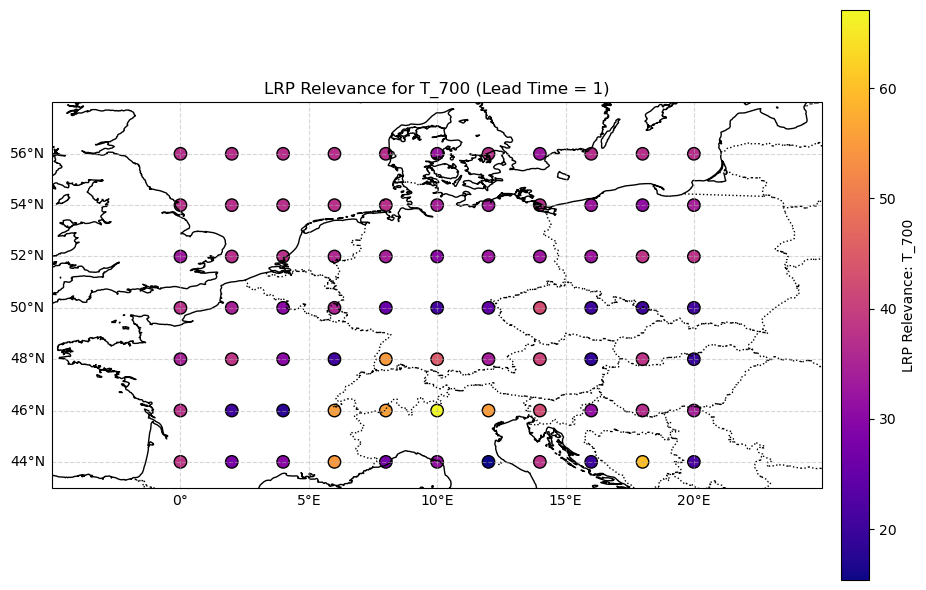

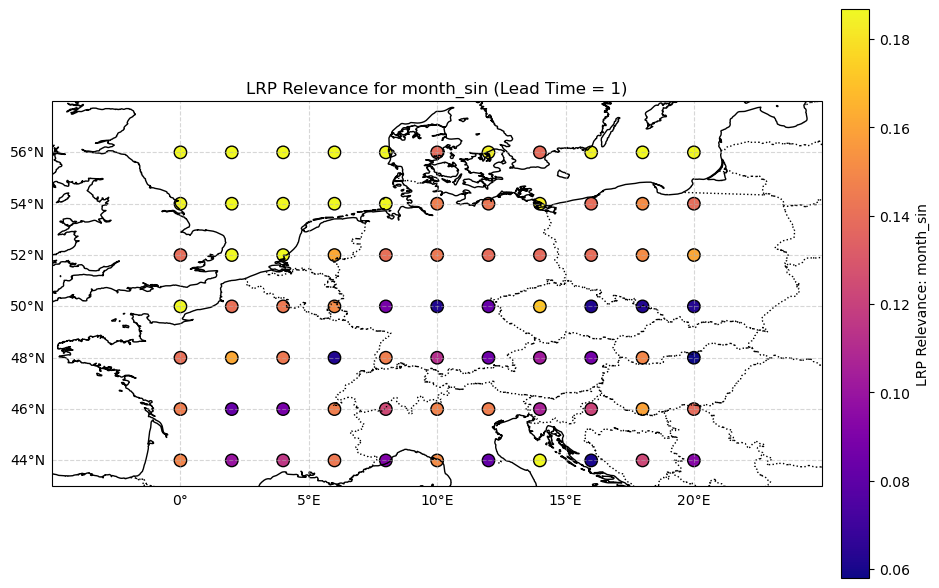

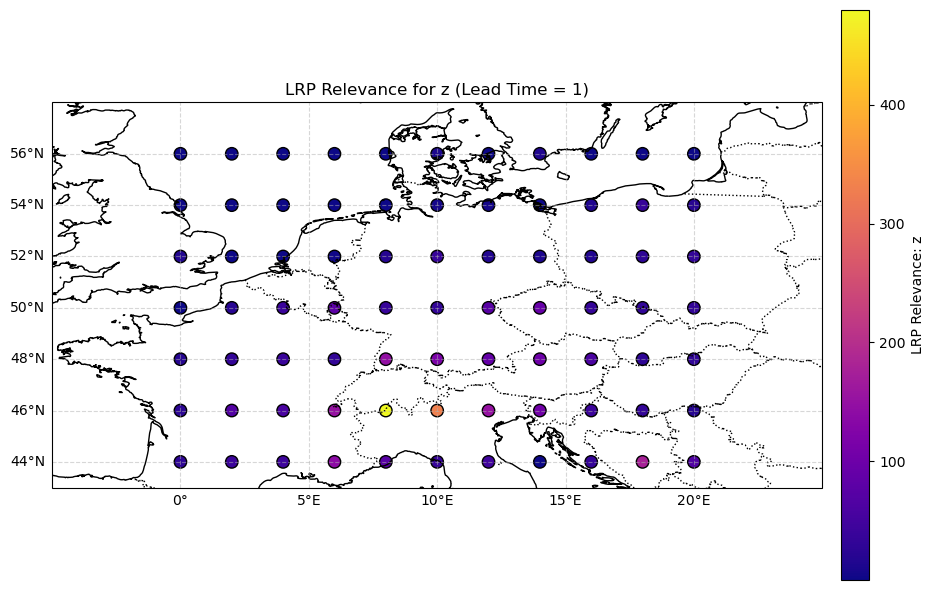

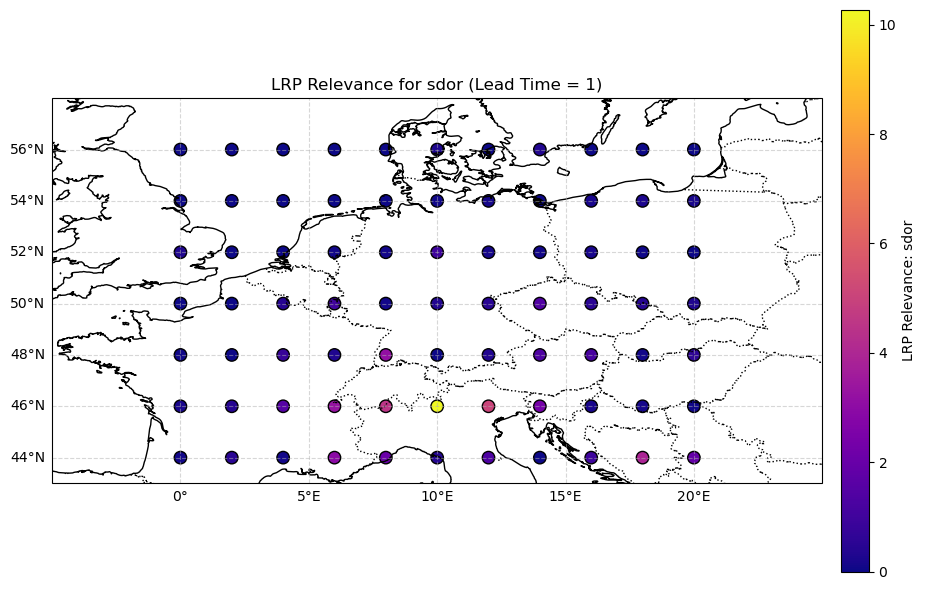

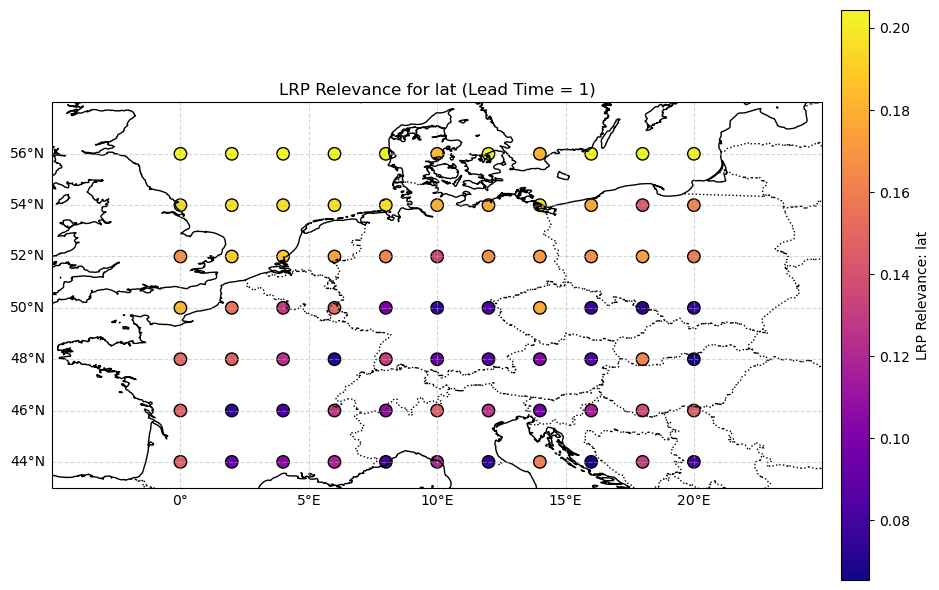

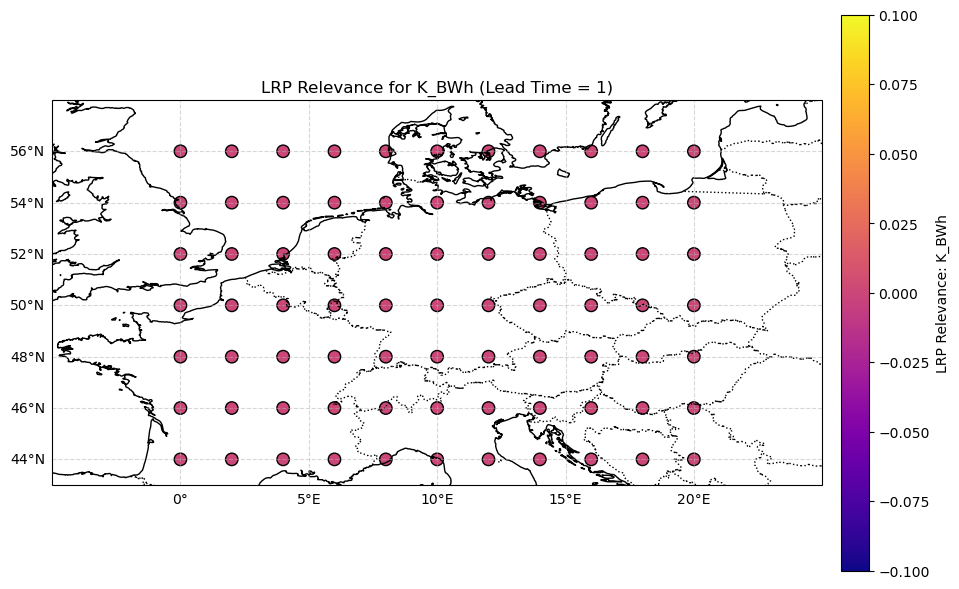

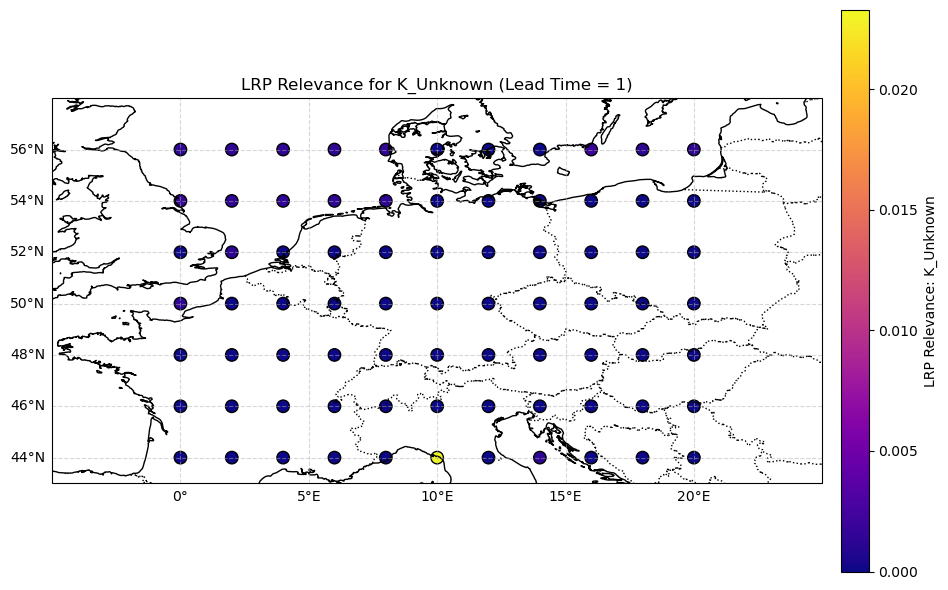

In [ ]:
lt_test = lead_time_test
# Step 1: Filter test set for lead time = 1
lead_time_flat = lt_test.flatten()
lead_time_value = 1  # change to 3, 5, 7 as needed

mask = (lead_time_flat == lead_time_value)

# Check how many you get
print("Num samples with lead time", lead_time_value, ":", np.sum(mask))

# Step 2: Slice X_test using that mask
X_test_lead1 = X_test.reshape(-1, X_test.shape[2])[mask]  # shape (N, F)

# Step 3: Reshape to (12, T, F) to match per-location structure
num_locations = len(latlon_grid)  # should be 66

X_test_lead1 = X_test_lead1.reshape(num_locations, -1, X_test.shape[2])

location_names = [f"{lat:.1f}°N, {lon:.1f}°E" for lat, lon in latlon_grid]

# Step 4: Run LRP by location
location_results = compute_lrp_by_location_absolute_mean(
    X_test_lead1, model, feature_names, location_names
)



# Now plot selected features for each location
selected_features = ['T_700', 'month_sin', 'z', 'sdor', 'lat', 'K_BWh','K_Unknown']
feature_indices = [feature_names.index(f) for f in selected_features]

import matplotlib.pyplot as plt
for idx, fname in zip(feature_indices, selected_features):
    values = [location_results[loc][idx] for loc in location_names]

    plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-5, 25, 43, 58], crs=ccrs.PlateCarree())

    # Map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    latitudes = np.array([lat for lat, lon in latlon_grid])
    longitudes = np.array([lon for lat, lon in latlon_grid])
    # Plot relevance as color
    sc = ax.scatter(
        longitudes, latitudes,
        c=values,
        cmap='plasma',  # or 'viridis', 'coolwarm'
        s=80,
        edgecolor='k'
    )

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label(f"LRP Relevance: {fname}")

    # Title
    plt.title(f"LRP Relevance for {fname} (Lead Time = {lead_time_value})")
    plt.tight_layout()
    plt.show()

🗻 Z range for plot: -9.4 to 2149.4 m
🌍 Köppen climate codes present in map: [7, 8, 9, 14, 15, 16, 18, 25, 26, 27, 29]
📋 Short Köppen classes: ['BSk', 'Csa', 'Csb', 'Cfa', 'Cfb', 'Cfc', 'Dsb', 'Dfa', 'Dfb', 'Dfc', 'ET']
🔢 Number of unique Köppen classes: 11


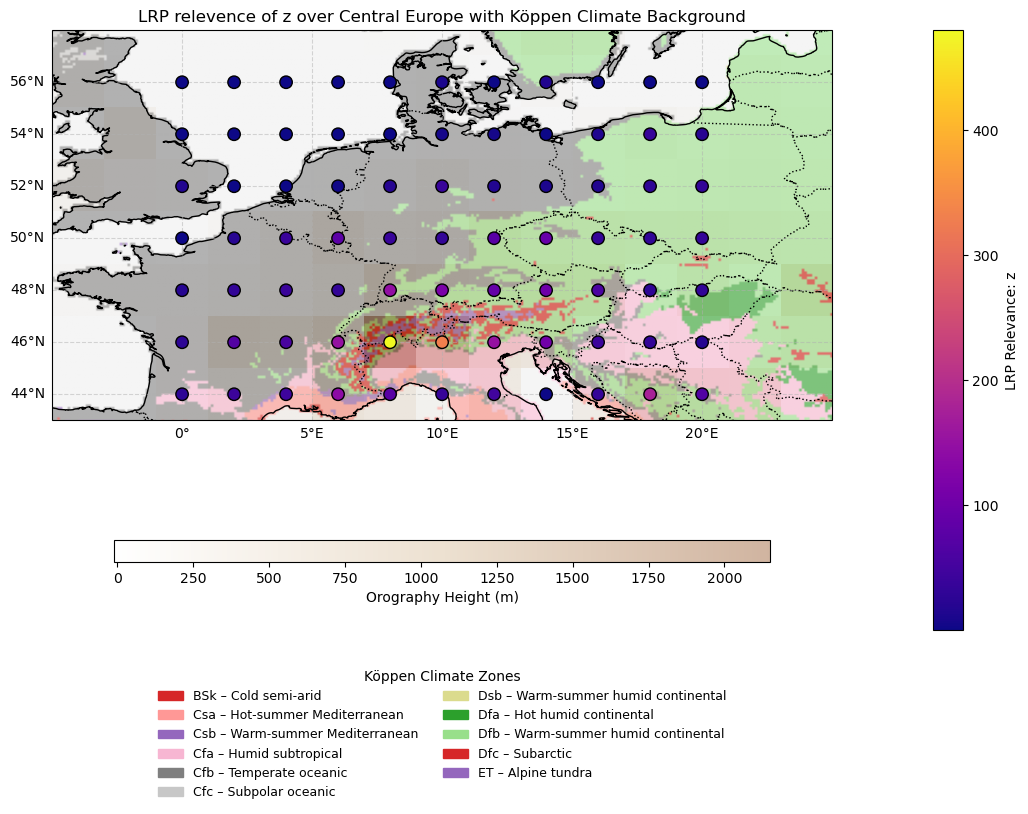

In [66]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np
import rasterio
from sklearn.metrics import mean_squared_error
from matplotlib.colors import LinearSegmentedColormap

white_to_darkbrown = LinearSegmentedColormap.from_list(
    "white_darkbrown", ["#ffffff", "#d2b48c", "saddlebrown"]  # white → tan → dark brown
)

# --- Compute RMSE per location ---
y_pred_2d = y_pred_real.reshape(len(latlon_grid), -1)
y_true_2d = y_true_real.reshape(len(latlon_grid), -1)
rmse_per_point = np.sqrt(np.mean((y_pred_2d - y_true_2d) ** 2, axis=1))

# --- Prepare lat/lon arrays ---
latitudes_all = np.array([lat for lat, lon in latlon_grid])
longitudes_all = np.array([lon for lat, lon in latlon_grid])

# --- Load Köppen raster ---
src_koppen = rasterio.open("/Users/yeganehkhabbazian/Downloads/koppen_geiger_0p1.tif")
koppen_data = src_koppen.read(1)
transform = src_koppen.transform

# --- Define full names for known Köppen classes ---
# --- Full mappings: raster value → abbreviation and full name ---
koppen_code_to_abbrev = {
    1: "Af", 2: "Am", 3: "Aw", 4: "BWh", 5: "BWk", 6: "BSh", 7: "BSk",
    8: "Csa", 9: "Csb", 10: "Csc", 11: "Cwa", 12: "Cwb", 13: "Cwc",
    14: "Cfa", 15: "Cfb", 16: "Cfc", 17: "Dsa", 18: "Dsb", 19: "Dsc", 20: "Dsd",
    21: "Dwa", 22: "Dwb", 23: "Dwc", 24: "Dwd", 25: "Dfa", 26: "Dfb",
    27: "Dfc", 28: "Dfd", 29: "ET", 30: "EF"
}

koppen_abbrev_to_full = {
    "Af": "Tropical rainforest", "Am": "Tropical monsoon", "Aw": "Tropical savanna",
    "BWh": "Hot desert", "BWk": "Cold desert", "BSh": "Hot semi-arid", "BSk": "Cold semi-arid",
    "Csa": "Hot-summer Mediterranean", "Csb": "Warm-summer Mediterranean", "Csc": "Cold-summer Mediterranean",
    "Cwa": "Subtropical monsoon", "Cwb": "Subtropical highland", "Cwc": "Cold subtropical highland",
    "Cfa": "Humid subtropical", "Cfb": "Temperate oceanic", "Cfc": "Subpolar oceanic",
    "Dsa": "Hot-summer humid continental", "Dsb": "Warm-summer humid continental",
    "Dsc": "Cold-summer humid continental", "Dsd": "Extremely cold-summer continental",
    "Dwa": "Monsoon-influenced humid continental", "Dwb": "Dry-winter warm-summer continental",
    "Dwc": "Dry-winter cold-summer continental", "Dwd": "Dry-winter extremely cold-summer continental",
    "Dfa": "Hot humid continental", "Dfb": "Warm-summer humid continental",
    "Dfc": "Subarctic", "Dfd": "Extremely cold subarctic", "ET": "Alpine tundra", "EF": "Polar ice cap"
}

# --- Assign distinct colors using tab20 colormap ---
color_map = plt.cm.tab20.colors
koppen_color_map = {code: color_map[i % 20] for i, code in enumerate(koppen_code_to_abbrev.keys())}

# --- Create background RGBA image using all valid present classes ---
colored_koppen = np.zeros((*koppen_data.shape, 4))
present_codes = np.unique(koppen_data)
present_codes = [c for c in present_codes if c in koppen_code_to_abbrev]

for code in present_codes:
    color = koppen_color_map[code]
    rgba = plt.matplotlib.colors.to_rgba(color)
    colored_koppen[koppen_data == code] = rgba

# Set unknown areas to light gray
colored_koppen[(koppen_data < 1) | (koppen_data > 30)] = plt.matplotlib.colors.to_rgba("#f0f0f0")




# --- Get extent of raster ---
left, bottom = transform * (0, koppen_data.shape[0])
right, top = transform * (koppen_data.shape[1], 0)
extent = [left, right, bottom, top]
# --- Load and convert orography z ---
z_height = z_data / 9.80665  # convert to meters

# --- Crop to map extent
lat_min, lat_max = 43, 58
lon_min, lon_max = -5, 25
z_crop = z_height.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
min_z = float(z_crop.min())
max_z = float(z_crop.max())
print(f"🗻 Z range for plot: {min_z:.1f} to {max_z:.1f} m")

# --- Plot ---
# --- Detect number of Köppen classes present in the plotted map region ---
# --- Detect number of Köppen classes present in the plotted map region ---
row_start, col_start = src_koppen.index(lon_min, lat_max)
row_stop, col_stop = src_koppen.index(lon_max, lat_min)
koppen_crop = koppen_data[min(row_start, row_stop):max(row_start, row_stop),
                          min(col_start, col_stop):max(col_start, col_stop)]

present_codes = np.unique(koppen_crop)
present_codes = [c for c in present_codes if c in koppen_code_to_abbrev]
present_abbrevs = [koppen_code_to_abbrev[c] for c in present_codes]

print(f"🌍 Köppen climate codes present in map: {present_codes}")
print(f"📋 Short Köppen classes: {present_abbrevs}")
print(f"🔢 Number of unique Köppen classes: {len(present_abbrevs)}")




fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-5, 25, 43, 58], crs=ccrs.PlateCarree())

# --- Background Köppen shading ---
ax.imshow(colored_koppen, origin='upper', extent=extent, transform=ccrs.PlateCarree(), zorder=0)
im = z_height.plot.imshow(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=white_to_darkbrown,
    alpha=0.4,
    zorder=1,
    vmin=min_z,
    vmax=max_z,
    add_colorbar=False,
    interpolation='nearest'  # or 'none'
)


# --- Borders and coastlines ---
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# --- Gridlines with lat/lon labels ---
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# --- RMSE scatter plot with red for high values ---
# --- LRP relevance scatter plot for T_700 ---
feature_to_plot = 'z'
idx = feature_names.index(feature_to_plot)
location_names = [f"{lat:.1f}°N, {lon:.1f}°E" for lat, lon in latlon_grid]
relevance_values = [location_results[loc][idx] for loc in location_names]

sc = ax.scatter(
    longitudes_all, latitudes_all,
    c=relevance_values,
    cmap='plasma',  # vibrant, good for attribution maps
    s=80,
    edgecolor='k',
    zorder=3
)
# After extracting present_codes from cropped region
# ✅ Already correct legend generation
legend_patches = []
for code in present_codes:
    abbrev = koppen_code_to_abbrev[code]
    full_name = koppen_abbrev_to_full.get(abbrev, "Unknown")
    color = koppen_color_map[code]
    label = f"{abbrev} – {full_name}"
    patch = mpatches.Patch(color=color, label=label)
    legend_patches.append(patch)

# ✅ Legend placement
plt.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -1),
           ncol=2, fontsize=9, title="Köppen Climate Zones", frameon=False)


# --- Colorbar for LRP relevance ---
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label(f"LRP Relevance: {feature_to_plot}")




cbar_z = plt.colorbar(
    im,
    ax=ax,
    orientation='horizontal',
    pad=0.2,
    shrink=0.7,
    aspect=30
)
cbar_z.set_label("Orography Height (m)")

# --- Final touches ---
plt.title("LRP relevence of z over Central Europe with Köppen Climate Background")
plt.tight_layout()
plt.show()


🗻 Z range for plot: -9.4 to 2149.4 m


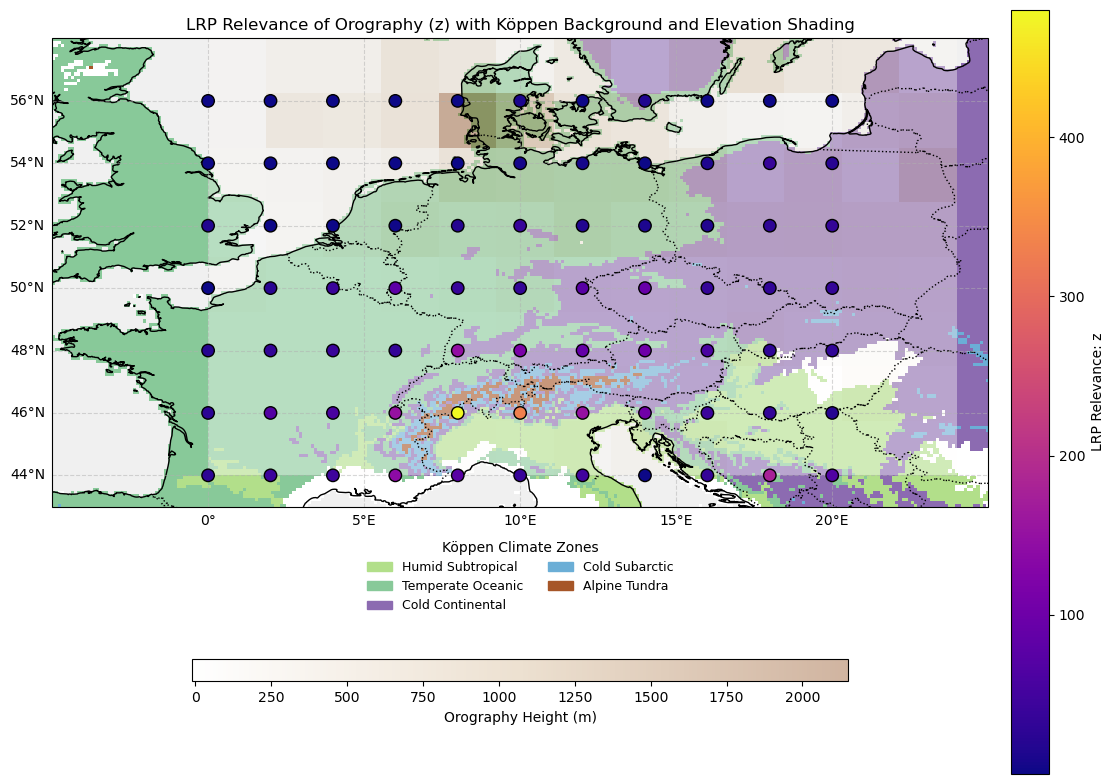

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np
import rasterio
from matplotlib.colors import LinearSegmentedColormap

# --- Custom colormap for orography ---
white_to_darkbrown = LinearSegmentedColormap.from_list(
    "white_darkbrown", ["#ffffff", "#d2b48c", "saddlebrown"]  # white → tan → dark brown
)

# --- Compute RMSE per location ---
y_pred_2d = y_pred_real.reshape(len(latlon_grid), -1)
y_true_2d = y_true_real.reshape(len(latlon_grid), -1)
rmse_per_point = np.sqrt(np.mean((y_pred_2d - y_true_2d) ** 2, axis=1))

# --- Prepare lat/lon arrays ---
latitudes_all = np.array([lat for lat, lon in latlon_grid])
longitudes_all = np.array([lon for lat, lon in latlon_grid])

# --- Load Köppen raster ---
src_koppen = rasterio.open("/Users/yeganehkhabbazian/Downloads/koppen_geiger_0p1.tif")
koppen_data = src_koppen.read(1)
transform = src_koppen.transform

# --- Koppen class definitions ---
koppen_lookup_full = {
    "Cfb": "Temperate Oceanic",
    "Dfb": "Cold Continental",
    "Dfc": "Cold Subarctic",
    "ET":  "Alpine Tundra",
    "Cfa": "Humid Subtropical",
    "Unknown": "Unknown"
}
koppen_color_map = {
    "Cfb": "#88c999",
    "Dfb": "#8c6bb1",
    "Dfc": "#6baed6",
    "ET":  "#a65628",
    "Cfa": "#b2df8a",
    "Unknown": "#f0f0f0"
}
koppen_code_to_short = {
    14: "Cfa", 15: "Cfb", 26: "Dfb", 27: "Dfc", 29: "ET"
}

# --- Convert raster to RGBA image ---
colored_koppen = np.zeros((*koppen_data.shape, 4))
for code, short in koppen_code_to_short.items():
    rgba = plt.matplotlib.colors.to_rgba(koppen_color_map.get(short, "#f0f0f0"))
    colored_koppen[koppen_data == code] = rgba
colored_koppen[(koppen_data < 1) | (koppen_data > 30)] = plt.matplotlib.colors.to_rgba("#f0f0f0")

# --- Raster extent ---
left, bottom = transform * (0, koppen_data.shape[0])
right, top = transform * (koppen_data.shape[1], 0)
extent = [left, right, bottom, top]

# --- Orography height ---
z_height = z_data / 9.80665
lat_min, lat_max = 43, 58
lon_min, lon_max = -5, 25
z_crop = z_height.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
min_z = float(z_crop.min())
max_z = float(z_crop.max())
print(f"🗻 Z range for plot: {min_z:.1f} to {max_z:.1f} m")

# --- Generate lat/lon edges for pcolormesh ---
lat_centers = z_crop.latitude.values
lon_centers = z_crop.longitude.values
lat_edges = np.linspace(lat_centers.min(), lat_centers.max(), len(lat_centers)+1)
lon_edges = np.linspace(lon_centers.min(), lon_centers.max(), len(lon_centers)+1)

# --- LRP relevance for selected feature ---
feature_to_plot = 'z'
idx = feature_names.index(feature_to_plot)
location_names = [f"{lat:.1f}°N, {lon:.1f}°E" for lat, lon in latlon_grid]
relevance_values = [location_results[loc][idx] for loc in location_names]

# === Plot ===
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-5, 25, 43, 58], crs=ccrs.PlateCarree())

# --- Köppen background ---
ax.imshow(colored_koppen, origin='upper', extent=extent, transform=ccrs.PlateCarree(), zorder=0)

# --- Orography with pcolormesh ---
z_data_plot = z_crop.values
pc = ax.pcolormesh(
    lon_edges,
    lat_edges,
    z_data_plot,
    cmap=white_to_darkbrown,
    vmin=min_z,
    vmax=max_z,
    shading='auto',
    transform=ccrs.PlateCarree(),
    alpha=0.4,
    zorder=1
)

# --- Map features ---
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# --- LRP scatter ---
sc = ax.scatter(
    longitudes_all, latitudes_all,
    c=relevance_values,
    cmap='plasma',
    s=80,
    edgecolor='k',
    zorder=3
)

# --- Colorbar for LRP ---
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label(f"LRP Relevance: {feature_to_plot}")

# --- Colorbar for Z ---
cbar_z = plt.colorbar(
    pc,
    ax=ax,
    orientation='horizontal',
    pad=0.2,
    shrink=0.7,
    aspect=30
)
cbar_z.set_label("Orography Height (m)")

# --- Legend for Köppen classes ---
present_codes = np.unique(koppen_data)
present_short = [koppen_code_to_short[c] for c in present_codes if c in koppen_code_to_short]
present_labels = [koppen_lookup_full[s] for s in present_short]
present_colors = [koppen_color_map[s] for s in present_short]
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(present_colors, present_labels)]
plt.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.25),
           ncol=2, fontsize=9, title="Köppen Climate Zones", frameon=False)

# --- Final ---
plt.title("LRP Relevance of Orography (z) with Köppen Background and Elevation Shading")
plt.tight_layout()
plt.show()


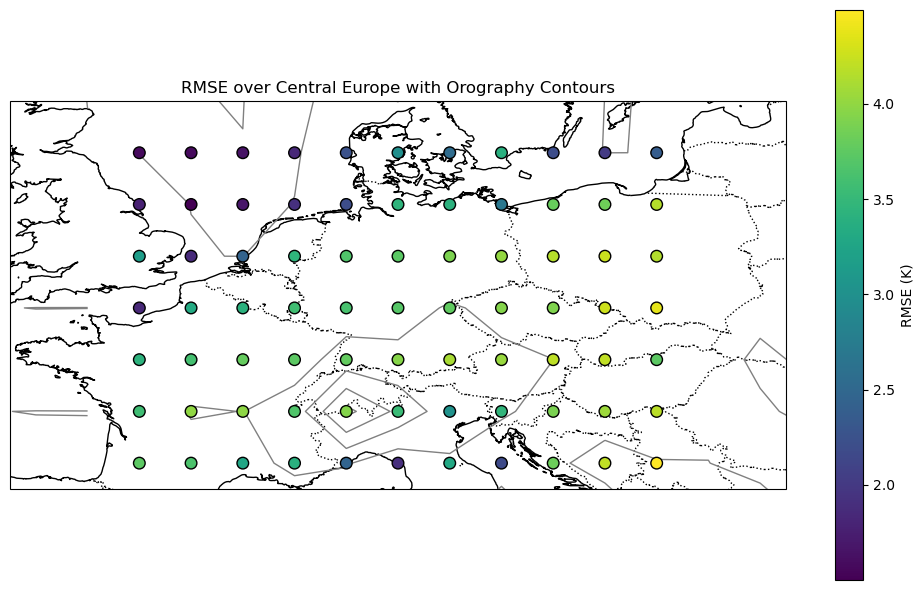

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
num_locations = len(latlon_grid)
latitudes_all = np.array(latitudes_all)
longitudes_all = np.array(longitudes_all)

# Step 1: Reshape (assumes 2D: locations × time)
y_true_2d = y_true_real.reshape(num_locations, -1)
y_pred_2d = y_pred_real.reshape(num_locations, -1)

# Step 2: Compute RMSE per grid point
rmse_per_point = np.sqrt(np.mean((y_pred_2d - y_true_2d) ** 2, axis=1))

# Step 3: Make sure you have lat/lon arrays
# For example: (these should match the order of predictions)
# all_lats = [50.0, 52.0, 54.0, ...]
# all_lons = [10.0, 12.0, 14.0, ...]

# Step 4: Plot


# Step 1: Convert geopotential to meters
z_height = z_data / 9.80665  # shape: (latitude, longitude), values in meters

# Step 2: Set up plot
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Step 3: Plot orography contours
# We'll use 500m intervals (0m to 3000m)
contour = z_height.plot.contour(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=np.arange(0, 3000 + 1, 500),
    colors='gray',
    linewidths=1.0,
    linestyles='solid',
    add_colorbar=False
)

# Optional: Label contour lines
ax.clabel(contour, fmt='%d m', inline=True, fontsize=8)

# Step 4: Plot RMSE points
sc = ax.scatter(longitudes_all, latitudes_all, c=rmse_per_point, cmap='viridis', s=70, edgecolor='k', zorder=3)
plt.colorbar(sc, label="RMSE (K)")

# Step 5: Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([-5, 25, 43, 58], crs=ccrs.PlateCarree())

plt.title("RMSE over Central Europe with Orography Contours")
plt.tight_layout()
plt.show()



In [ ]:
print("type(months_all):", type(months_all))

if isinstance(months_all, list):
    print("Length of months_all:", len(months_all))
    print("Type of first element:", type(months_all[0]))
    print("Shape of first element:", np.shape(months_all[0]))
else:
    print("months_all is NOT a list anymore! It is shape:", np.shape(months_all))
# 🛠️ Recover proper 2D shape (num_segments, num_timesteps)
months_all = months_all.reshape(48, 7298)
print("✅ Recovered shape:", months_all.shape)
# Safeguard recovery
months_all_list = months_all.tolist()  # save clean version
# Get current size
total_len = len(months_all)
print("Current flat length:", total_len)

# Try possible values for num_segments
for seg in range(1, 200):
    if total_len % seg == 0:
        print(f"{seg} × {total_len // seg} = {total_len}")
def compute_lrp_by_month_absolute_mean(X_numpy, month_array, model, feature_names):
    """
    Compute the mean absolute LRP relevance for each feature, grouped by month.
    Automatically adds dummy lead_time column if missing.
    """
    from zennit.composites import EpsilonPlus
    from zennit.attribution import Gradient as Attribution
    import torch
    import numpy as np
    import matplotlib.pyplot as plt

    composite = EpsilonPlus()
    month_array = np.array(month_array)
    results = {}

    # ✅ Fix input shape by adding dummy lead_time if needed
    if X_numpy.shape[1] == len(feature_names) - 1:
        print("⚠️ Adding dummy lead_time column...")
        lead_time_dummy = np.zeros((X_numpy.shape[0], 1), dtype=np.float32)
        X_numpy = np.concatenate([X_numpy, lead_time_dummy], axis=1)

    for month in range(1, 13):
        mask = (month_array == month)
        X_subset = X_numpy[mask]

        print(f"📆 Month {month}: {X_subset.shape[0]} samples")

        relevance_all = []
        for i in range(X_subset.shape[0]):
            x_input = torch.tensor(X_subset[i:i+1], dtype=torch.float32, requires_grad=True)
            with Attribution(model=model, composite=composite) as attr:
                _, relevance = attr(x_input)
                relevance_all.append(np.abs(relevance.detach().numpy().flatten()))

        relevance_all = np.array(relevance_all)
        abs_mean = np.mean(relevance_all, axis=0)
        results[month] = abs_mean

    return results

type(months_all): <class 'numpy.ndarray'>
months_all is NOT a list anymore! It is shape: (2247784,)


ValueError: cannot reshape array of size 2247784 into shape (48,7298)

In [ ]:
months_all_2d=months_all_list
# ✅ STEP 1: Align months_all to X_all
# Get correct number of time steps from the actual data
true_timesteps = X_all.shape[1]  # e.g., 7292

# If months_all had extra time steps (like 7298), trim each array
months_all_list = [arr[:true_timesteps] for arr in months_all]

# Convert list of 1D arrays to a clean 2D array: (num_segments, num_timesteps)
months_all_2d = np.stack(months_all_list, axis=0)
print("✅ months_all_2d shape:", months_all_2d.shape)  # should match (48, 7292)

# ✅ STEP 2: Define split points consistent with how you split X_all
num_segments = X_all.shape[0]
num_time_steps = X_all.shape[1]  # this is now trusted

split_index = int(num_time_steps * 0.85)        # 85% for train+val
val_split   = int(split_index * 0.85)           # 85% of that for train

# ✅ STEP 3: Slice months to train / val / test
month_train_2d = months_all_2d[:, :val_split]                 # 85% of 85%
month_val_2d   = months_all_2d[:, val_split:split_index]      # 15% of 85%
month_test_2d  = months_all_2d[:, split_index:]               # last 15%

# ✅ STEP 4: Flatten them to match sample layout of your input data
train_months_flat = month_train_2d.flatten()
val_months_flat   = month_val_2d.flatten()
test_months_flat  = month_test_2d.flatten()

# ✅ STEP 5: Confirm everything aligns
print("Train months flat shape:", train_months_flat.shape)
print("Val months flat shape  :", val_months_flat.shape)
print("Test months flat shape :", test_months_flat.shape)
print("X_test_clean shape     :", X_test_clean.shape)
X_flat = X_test_clean.reshape(-1, X_test_clean.shape[-1])      # (48*T, features)
months_flat = months_all.reshape(-1)                           # (48*T,)

# ✅ STEP 6: Use test_months_flat in your LRP function
monthly_results = compute_lrp_by_month_absolute_mean(X_test_clean, test_months_flat, model, feature_names)

# ✅ STEP 7: Plot selected features over months
selected_features = ['T_700', 'T_500', 'z','lsm', 'sdor', 'lat', 'K_BWh', 'lon']
feature_indices = [feature_names.index(f) for f in selected_features]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for idx, fname in zip(feature_indices, selected_features):
    plt.plot(
        list(monthly_results.keys()),
        [monthly_results[m][idx] for m in monthly_results],
        label=fname
    )

plt.xlabel("Month")
plt.ylabel("Mean Absolute LRP Relevance")
plt.title("Feature Relevance Over Months")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
   
def compute_signed_month_effect(X_numpy, month_array, model, feature_names):
    from zennit.composites import EpsilonPlus
    from zennit.attribution import Gradient as Attribution
    import torch
    import numpy as np

    composite = EpsilonPlus()
    month_array = np.array(month_array)
    results = {}

    month_index = feature_names.index("month_sin")

    # ⚠️ Fix: Add dummy lead_time if needed
    if X_numpy.shape[1] == len(feature_names) - 1:
        lead_dummy = np.zeros((X_numpy.shape[0], 1), dtype=np.float32)
        X_numpy = np.concatenate([X_numpy, lead_dummy], axis=1)

    for month in range(1, 13):
        mask = (month_array == month)
        X_subset = X_numpy[mask]
        print(f"📆 Month {month}: {X_subset.shape[0]} samples")

        signed_relevance = []
        for i in range(X_subset.shape[0]):
            x_input = torch.tensor(X_subset[i:i+1], dtype=torch.float32, requires_grad=True)
            with Attribution(model=model, composite=composite) as attr:
                _, relevance = attr(x_input)
                signed_relevance.append(relevance.detach().numpy().flatten()[month_index])

        results[month] = np.mean(signed_relevance)

    return results


signed_month_effect = compute_signed_month_effect(X_test_clean, test_months_flat, model, feature_names)



plt.figure(figsize=(8, 4))
plt.plot(list(signed_month_effect.keys()), list(signed_month_effect.values()), marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Signed Relevance of 'month' Feature")
plt.xlabel("Month")
plt.ylabel("Signed Relevance ")
plt.grid(True)
plt.tight_layout()
plt.show()